# Lab 02: análisis y figuras (NVS, velas de 1 hora)

Este notebook **no contiene lógica**: importa funciones de `src/` y muestra lo que generó `python main.py`
(tablas en `resultados/`, figuras en `docs/figures/` y θ* en `docs/theta_congelado.json`).
Córrelo después de `python main.py`.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display

from src.data import auditar_datos, cargar_datos, separar_train_test_validacion
from src.optimize import cargar_theta

pd.set_option("display.width", 160)
R, F = ROOT / "resultados", ROOT / "docs" / "figures"
resumen = json.loads((R / "resumen.json").read_text(encoding="utf-8"))

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos y split

In [2]:
datos = cargar_datos(ROOT / "data" / "nvs_1h.csv")
train, test, validacion = separar_train_test_validacion(datos)
display(pd.Series(auditar_datos(datos)))
pd.DataFrame(resumen["split"], index=["inicio", "fin", "velas"]).T

velas                                      5072
dias                                        730
inicio                2023-11-07 09:30:00-05:00
fin                   2026-10-06 15:30:00-04:00
duplicados                                    0
nulos                                         0
ohlc_incoherente                              0
volumen_cero                                  0
dias_incompletos                              9
retorno_maximo_abs                     0.141716
dtype: object

,inicio,fin,velas
train,2023-11-07 09:30:00-05:00,2025-08-07 15:30:00-04:00,3046
test,2025-08-08 09:30:00-04:00,2026-03-09 15:30:00-04:00,1004
validation,2026-03-10 09:30:00-04:00,2026-10-06 15:30:00-04:00,1022


## 2. Estrategia: indicadores y operaciones

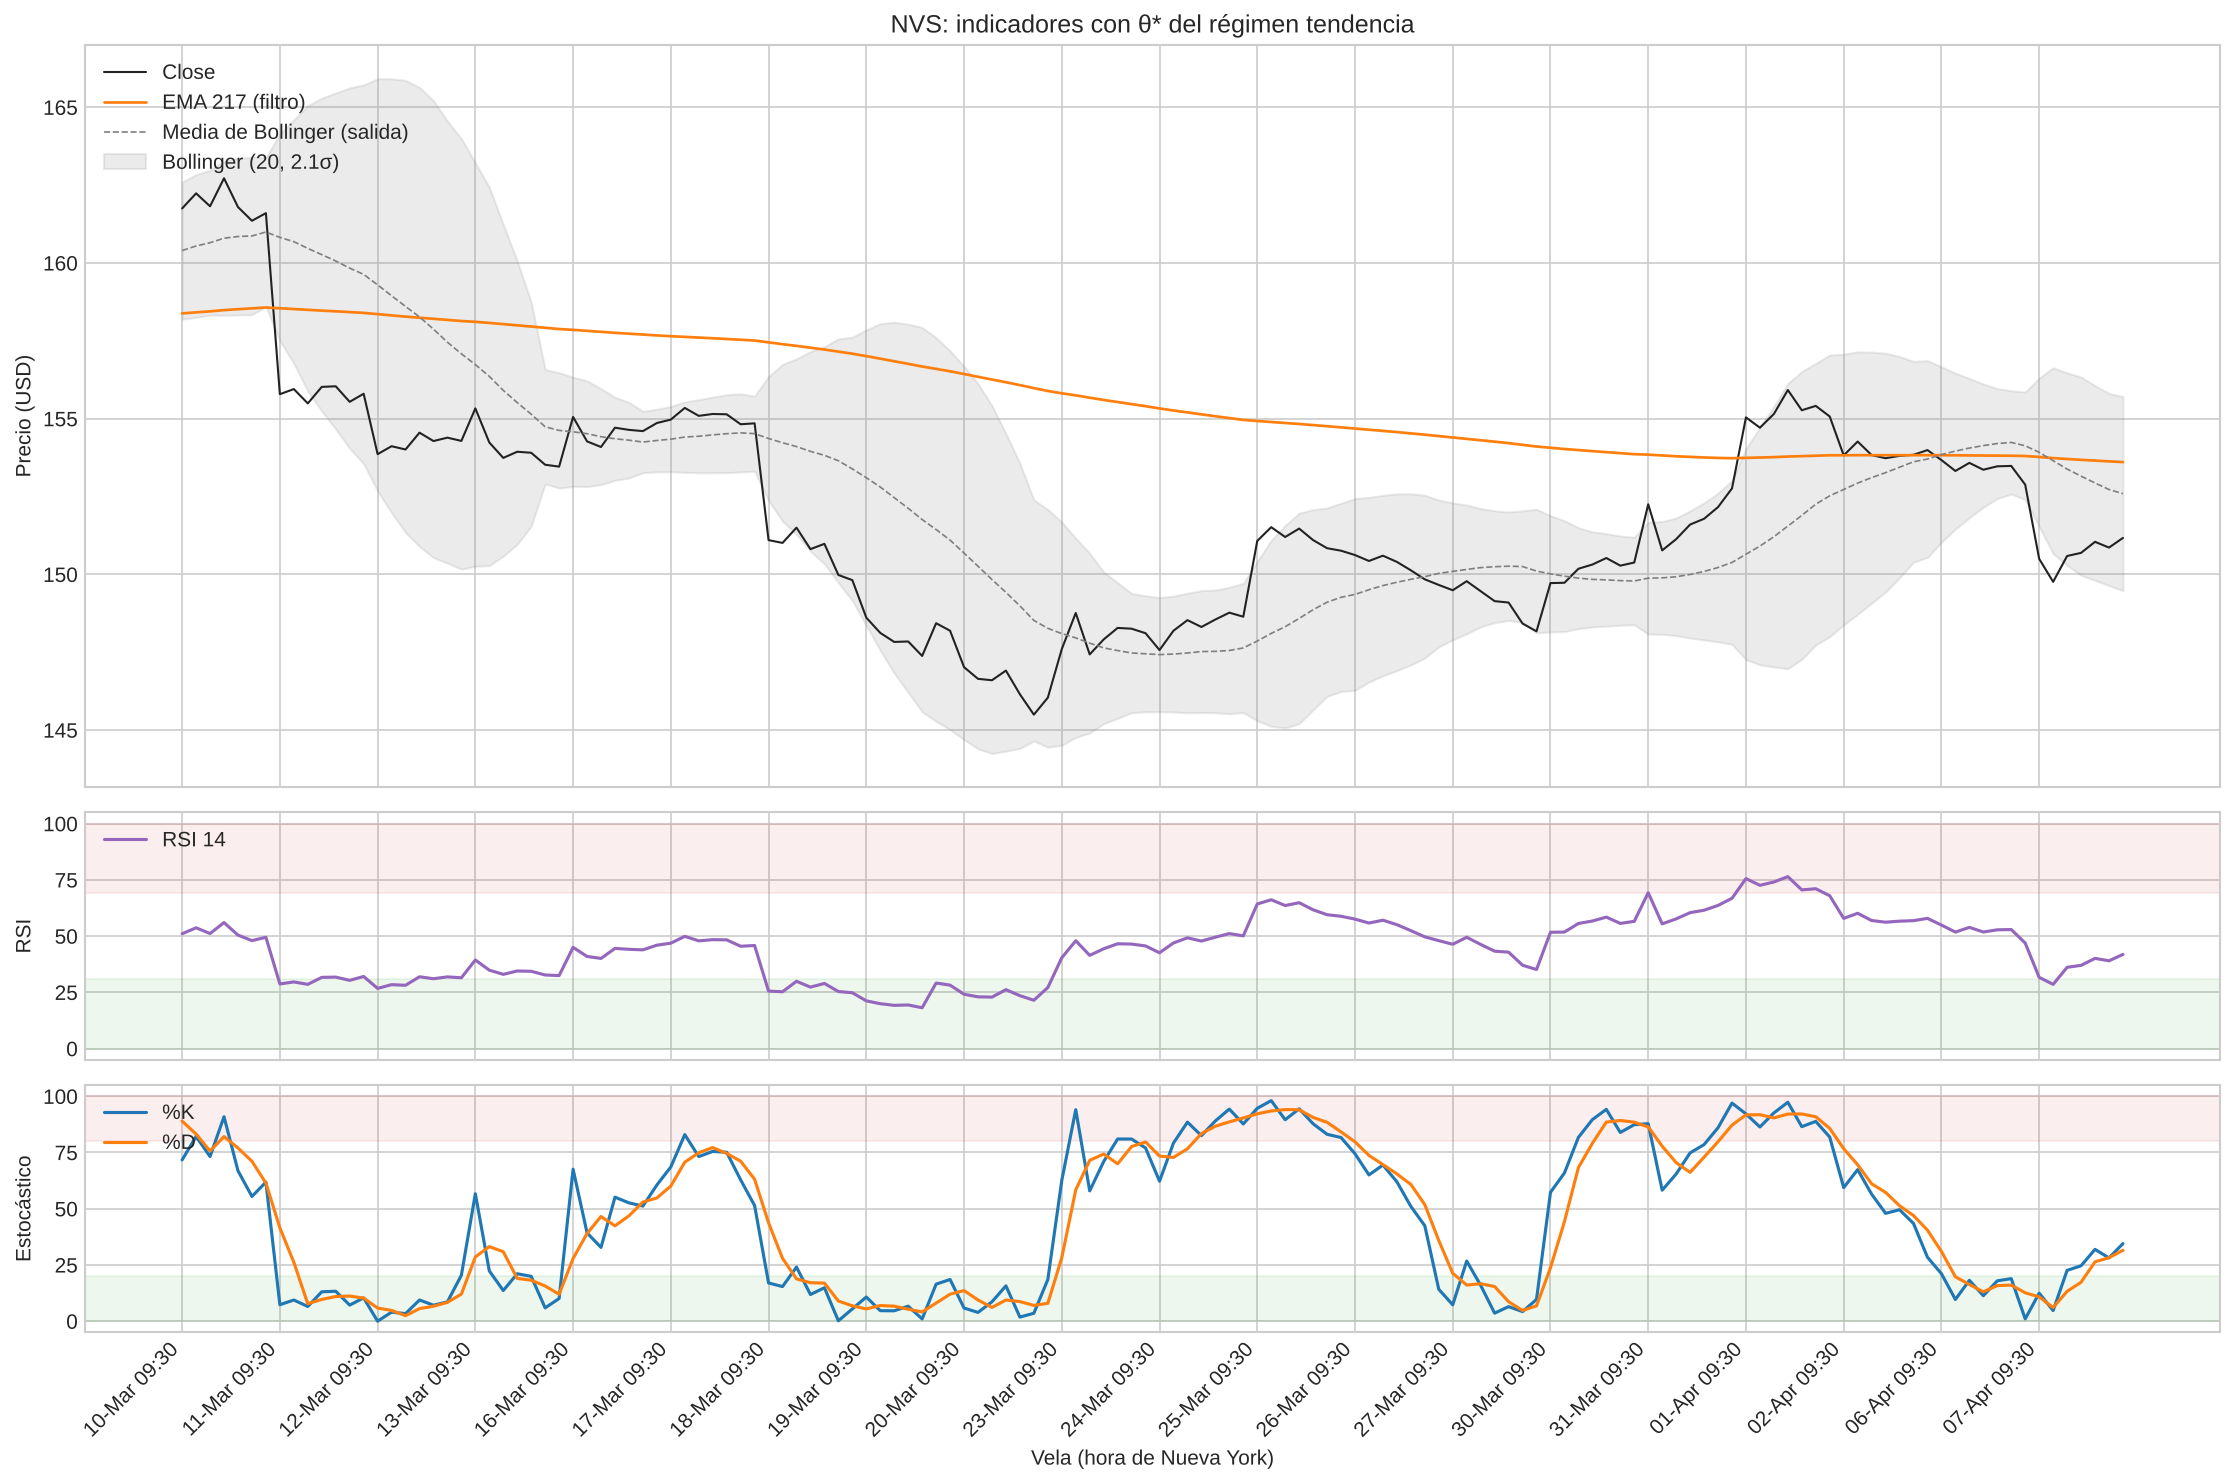

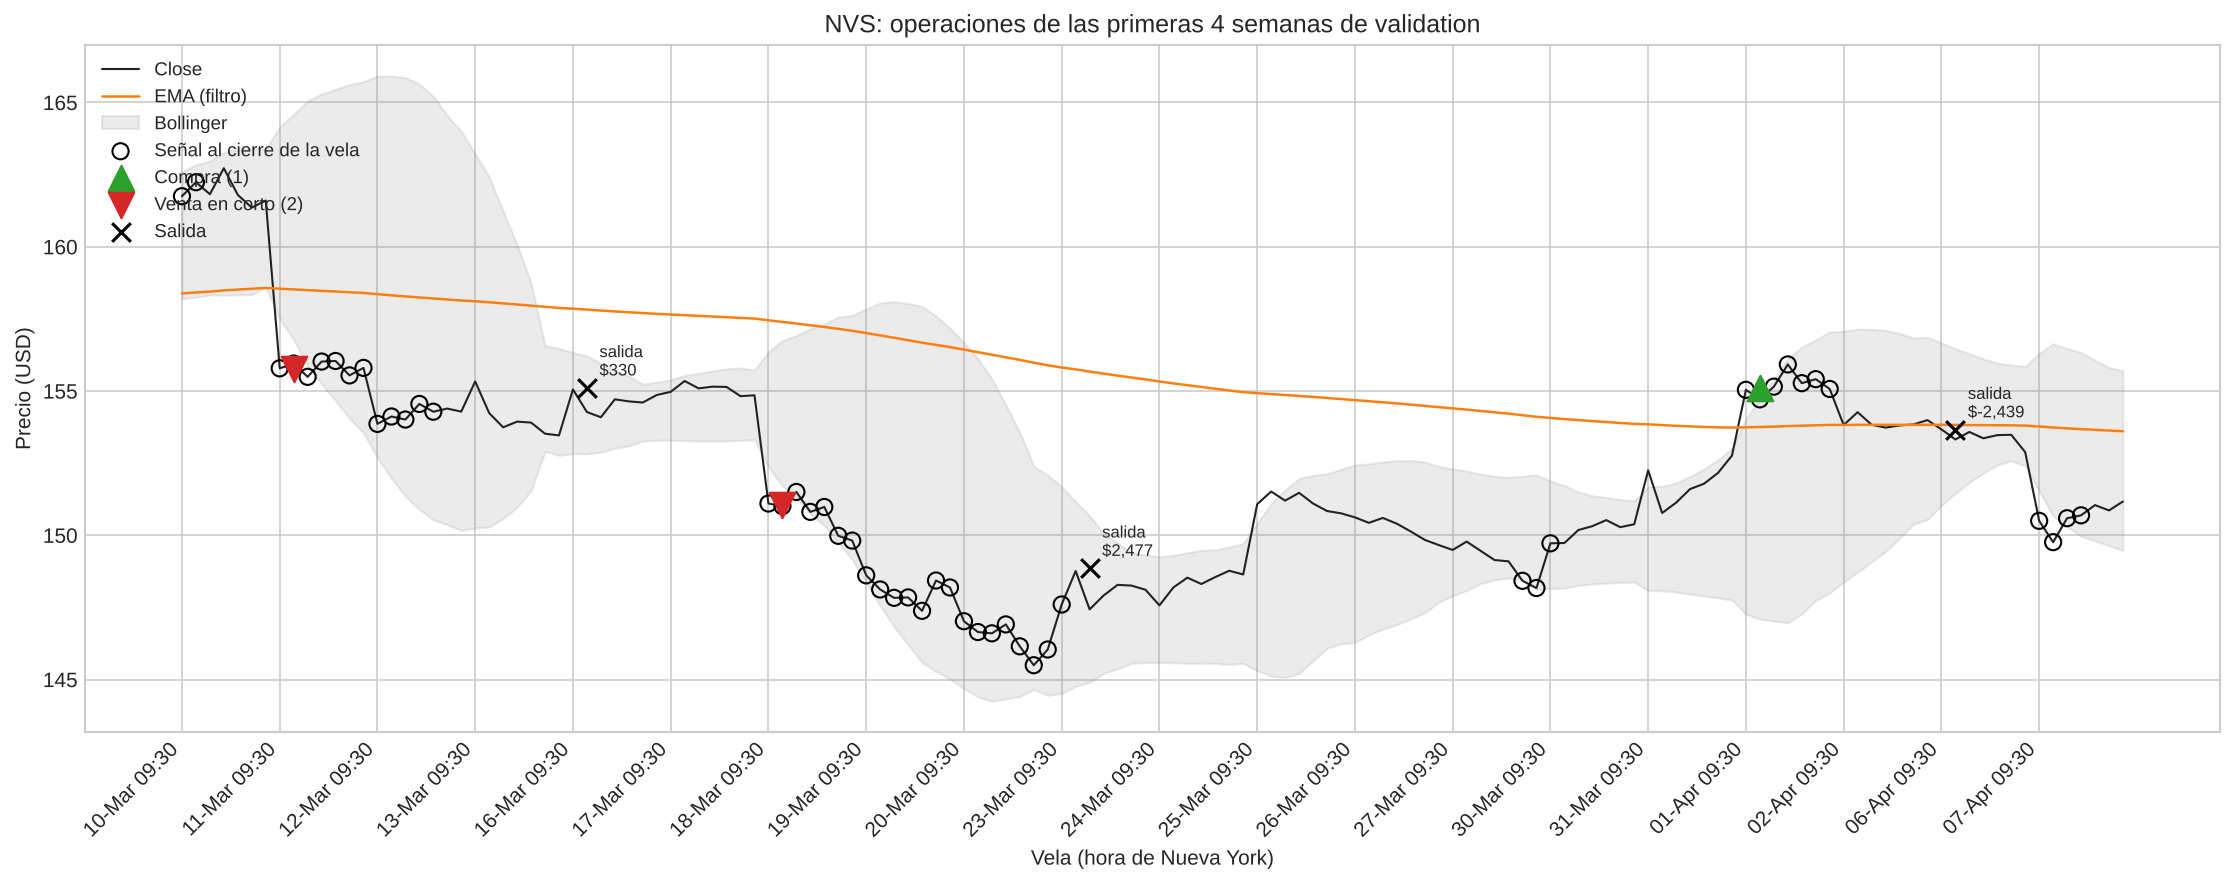

,dos_de_tres,estricta,solo_bollinger,solo_rsi,solo_estocastico
largos,553,203,325,476,929
cortos,399,132,203,362,620


In [3]:
display(Image(F / "01_indicadores.png"))
display(Image(F / "02_operaciones.png"))
pd.DataFrame(resumen["senales_base"])

## 3. Régimen de mercado

silhouette  duracion_media_h  transiciones_por_mes  part_tendencia  part_reversion  part_crisis
reglas      train       0.331            20.067                 7.277           0.291           0.460        0.249
            test        0.267            20.080                 7.174           0.299           0.371        0.331
kmeans      train       0.358            16.183                 9.035           0.318           0.348        0.334
            test        0.225            17.017                 8.492           0.331           0.251        0.418
hmm         train       0.261            24.472                 5.958           0.338           0.335        0.328
            test        0.189            31.375                 4.539           0.323           0.167        0.510
hmm_viterbi train       0.275            27.615                 5.274           0.357           0.323        0.320

Coincidencia HMM filtrado contra Viterbi en train: 0.938


,silhouette,duracion_media_h,transiciones_por_mes,part_tendencia,part_reversion,part_crisis,duracion_media_por_regimen
train,0.354218,17.5,8.351163,0.366777,0.366777,0.266445,"{'crisis': 21.1, 'reversion': 15.8, 'tendencia..."
test,0.273397,18.592593,7.75996,0.374502,0.262948,0.36255,"{'crisis': 26.0, 'reversion': 12.6, 'tendencia..."
validation,0.109334,16.754098,8.630137,0.172211,0.234834,0.592955,"{'crisis': 28.9, 'reversion': 10.0, 'tendencia..."


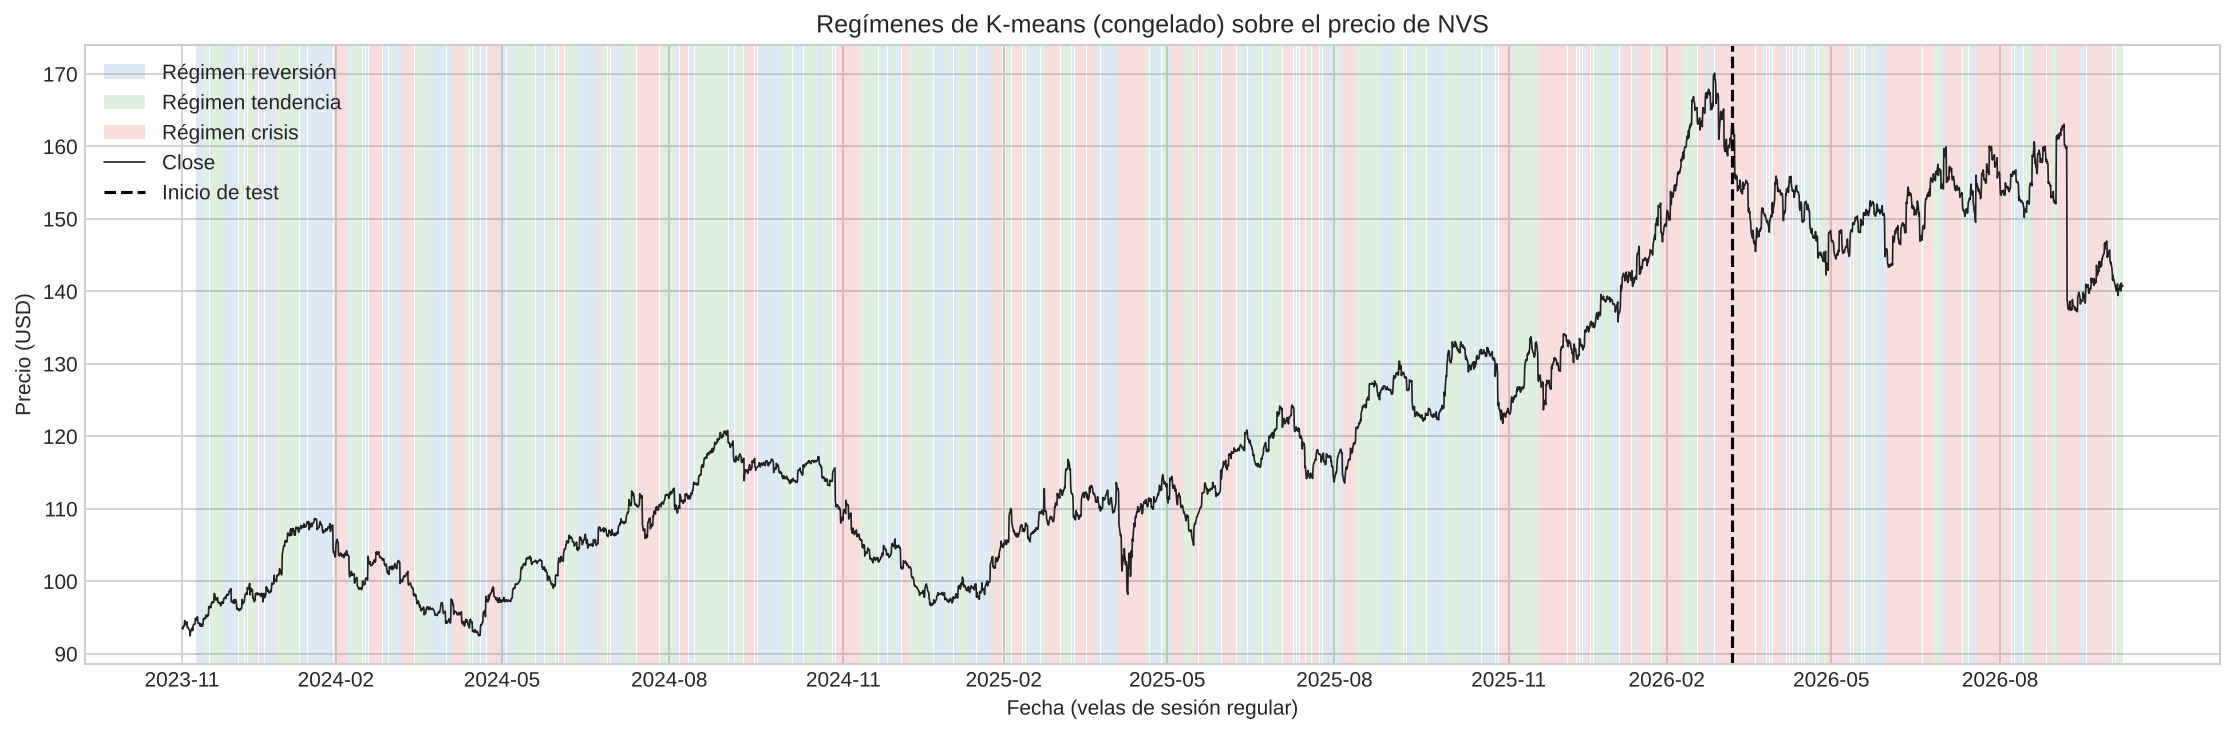

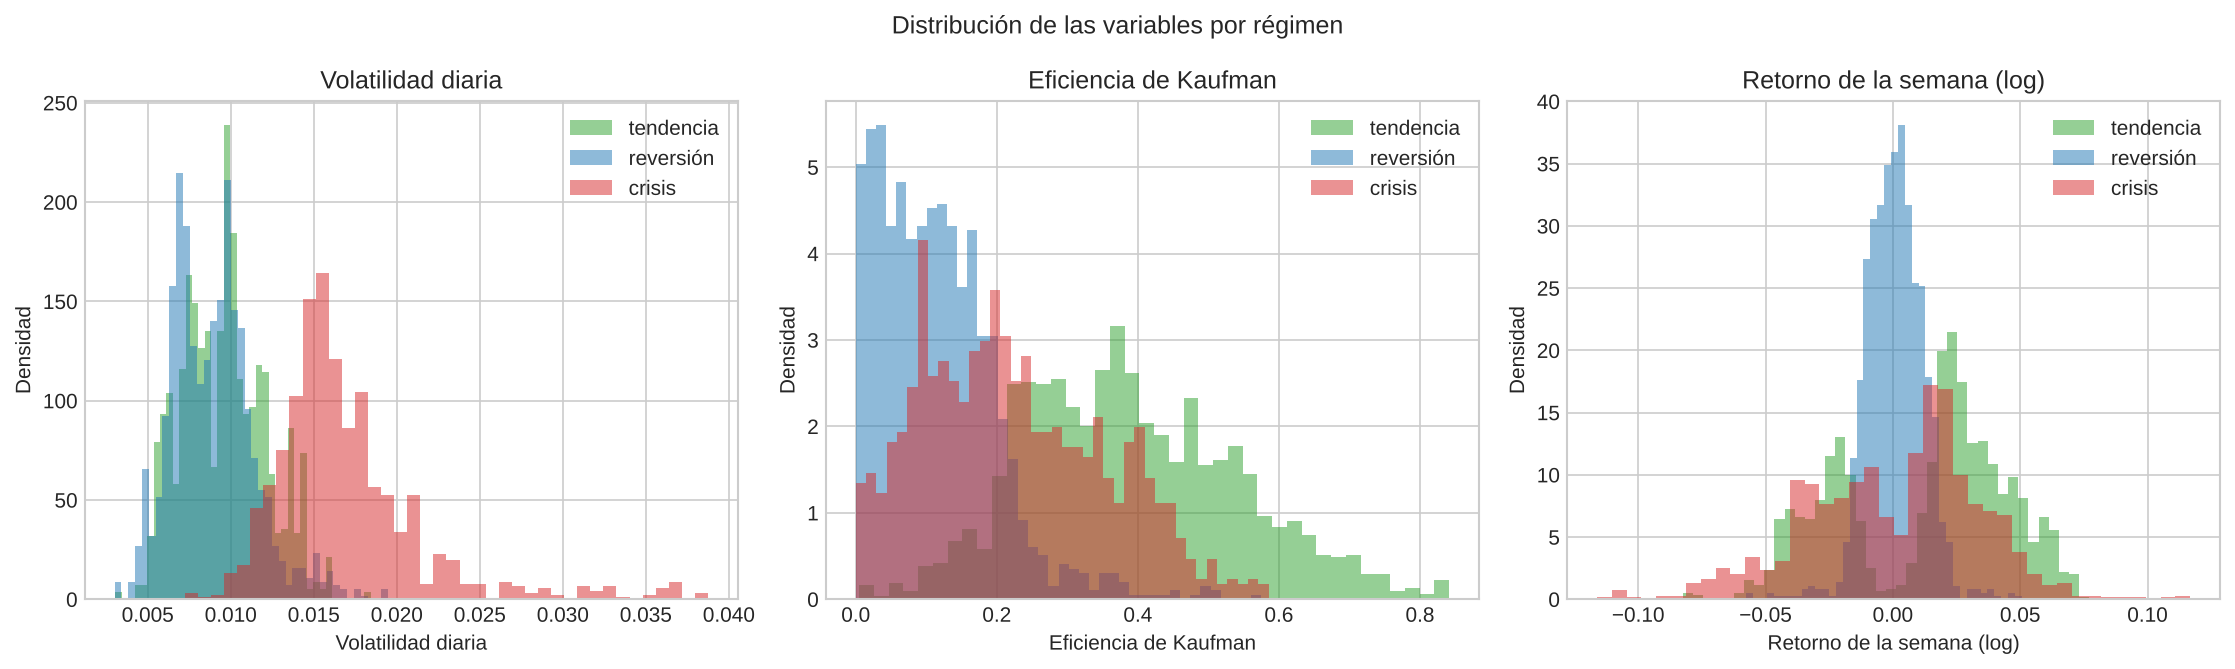

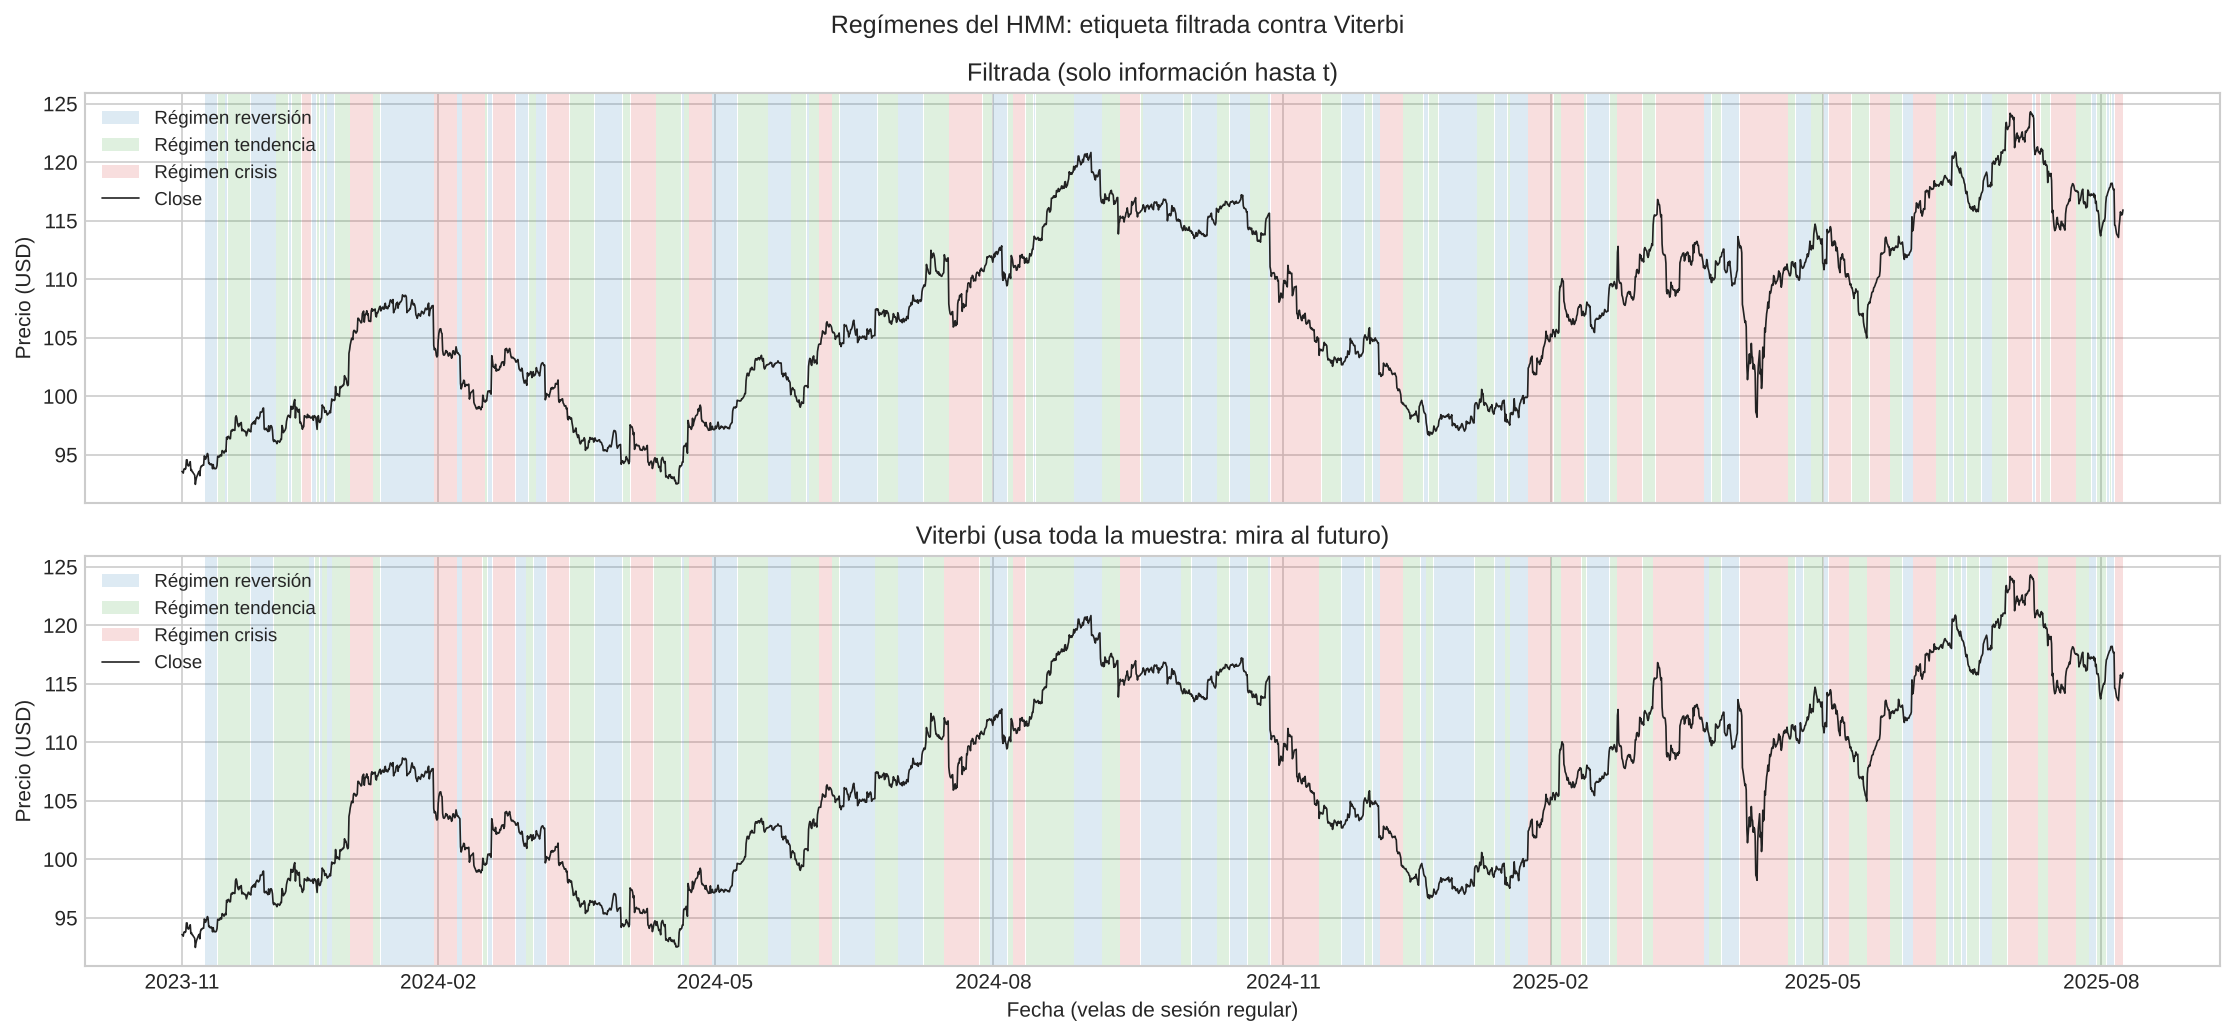

In [4]:
display(pd.read_csv(R / "clasificadores.csv", index_col=[0, 1]).round(3))
print("Coincidencia HMM filtrado contra Viterbi en train:", round(resumen["coincidencia_filtrada_viterbi"], 3))
display(pd.DataFrame(resumen["regimenes"]).T)
for f in ("07_regimenes_precio.png", "08_distribuciones_regimen.png", "16_hmm_filtrada_viterbi.png"):
    display(Image(F / f))

## 4. θ* congelado

In [5]:
theta = cargar_theta(ROOT / "docs" / "theta_congelado.json")
print("Optimizado de", theta["optimizado_desde"], "a", theta["optimizado_hasta"], "· commit", resumen.get("commit_theta"))
pd.DataFrame({r: p if p else {} for r, p in theta["parametros"].items()}).round(3)

Optimizado de 2023-11-07 09:30:00-05:00 a 2026-03-06 15:30:00-05:00 · commit 1ed717e 2026-10-06T20:57:49-06:00


,tendencia,reversion,crisis
estilo,ruptura,NaN,ruptura
bb_n,20,NaN,20
sto_bajo,20,NaN,20
memoria,3,NaN,3
tp_atr,12.0,NaN,12.0
max_velas,70,NaN,70
bb_k,2.127219,NaN,2.830611
rsi_bajo,31,NaN,30
ema_n,217,NaN,172
sl_atr,3.997312,NaN,9.588854


## 5. Optimización

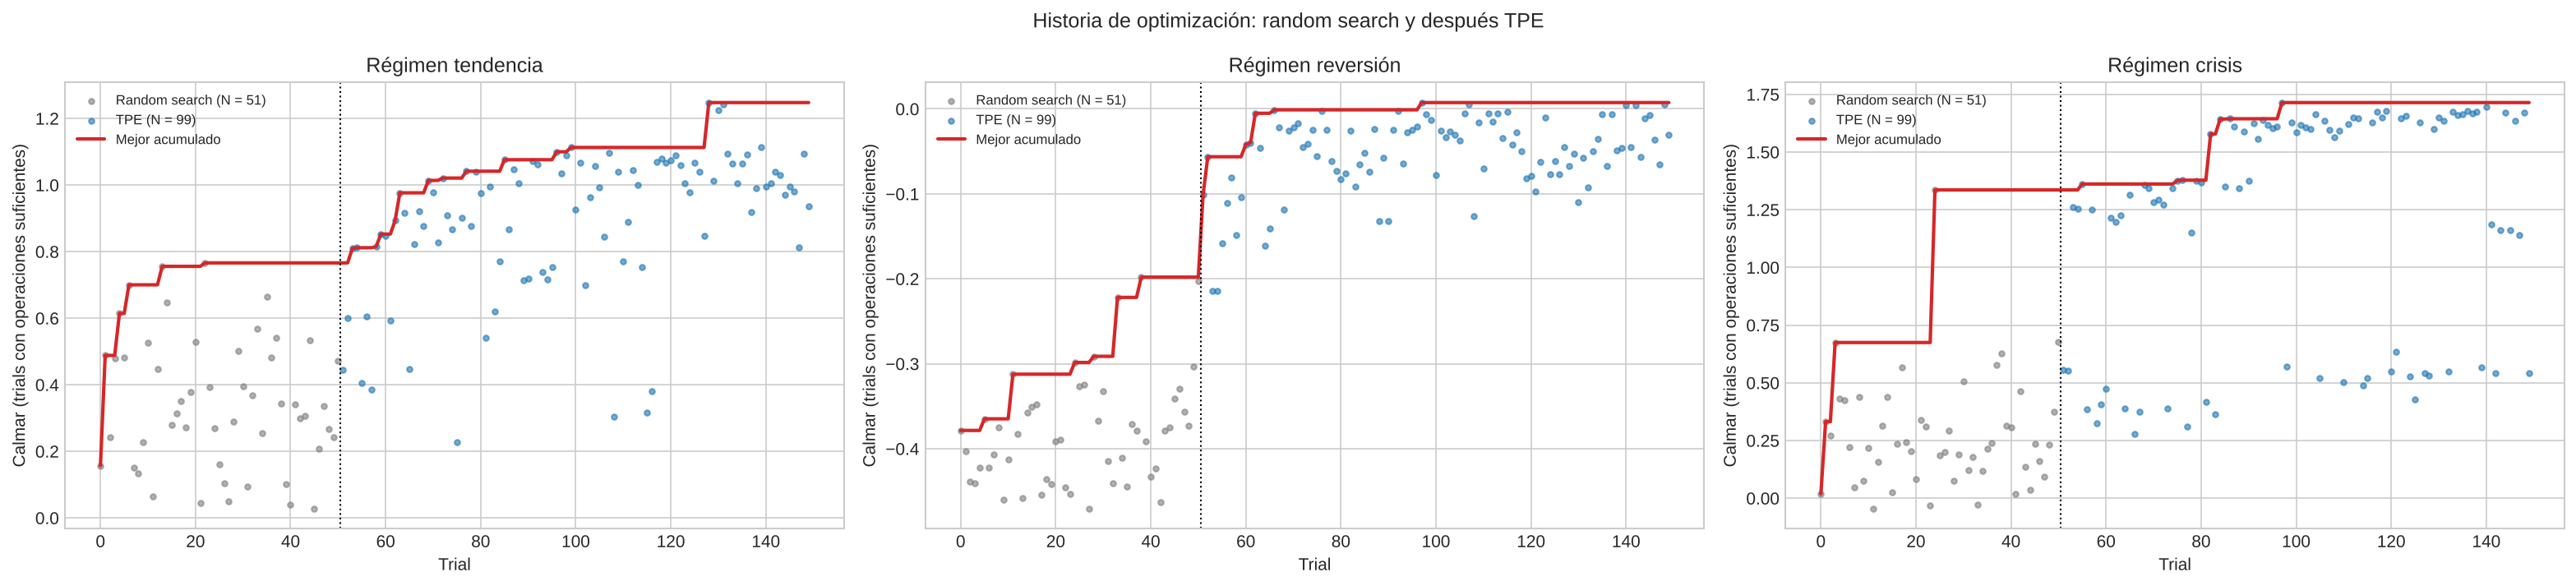

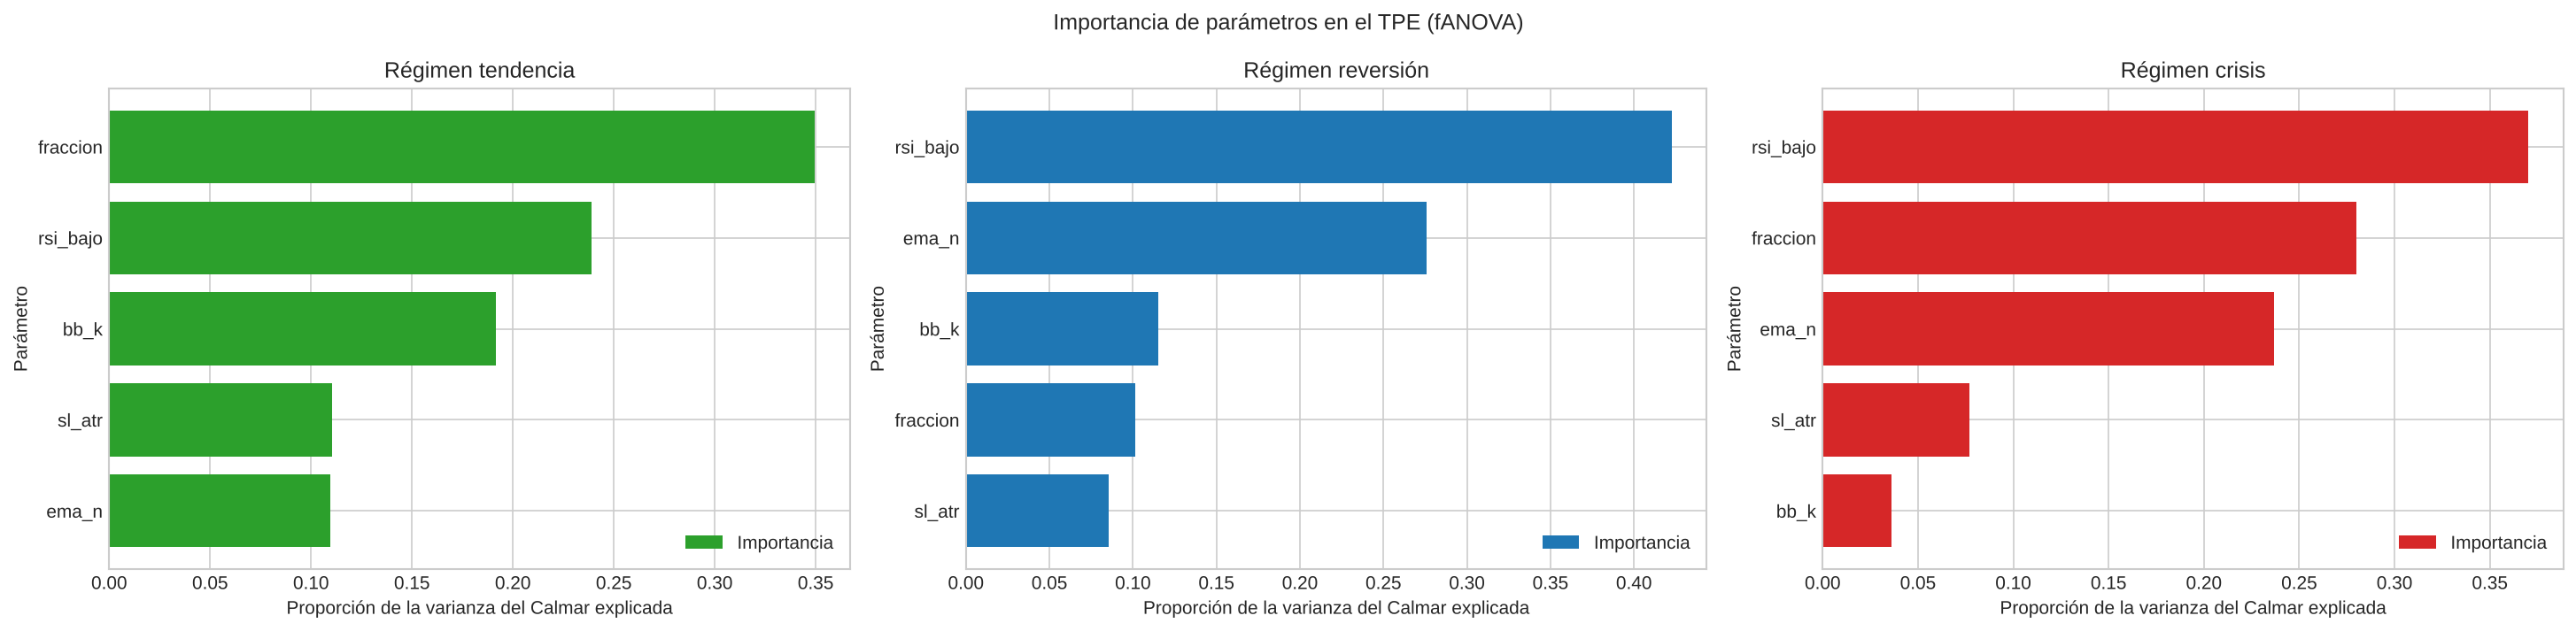

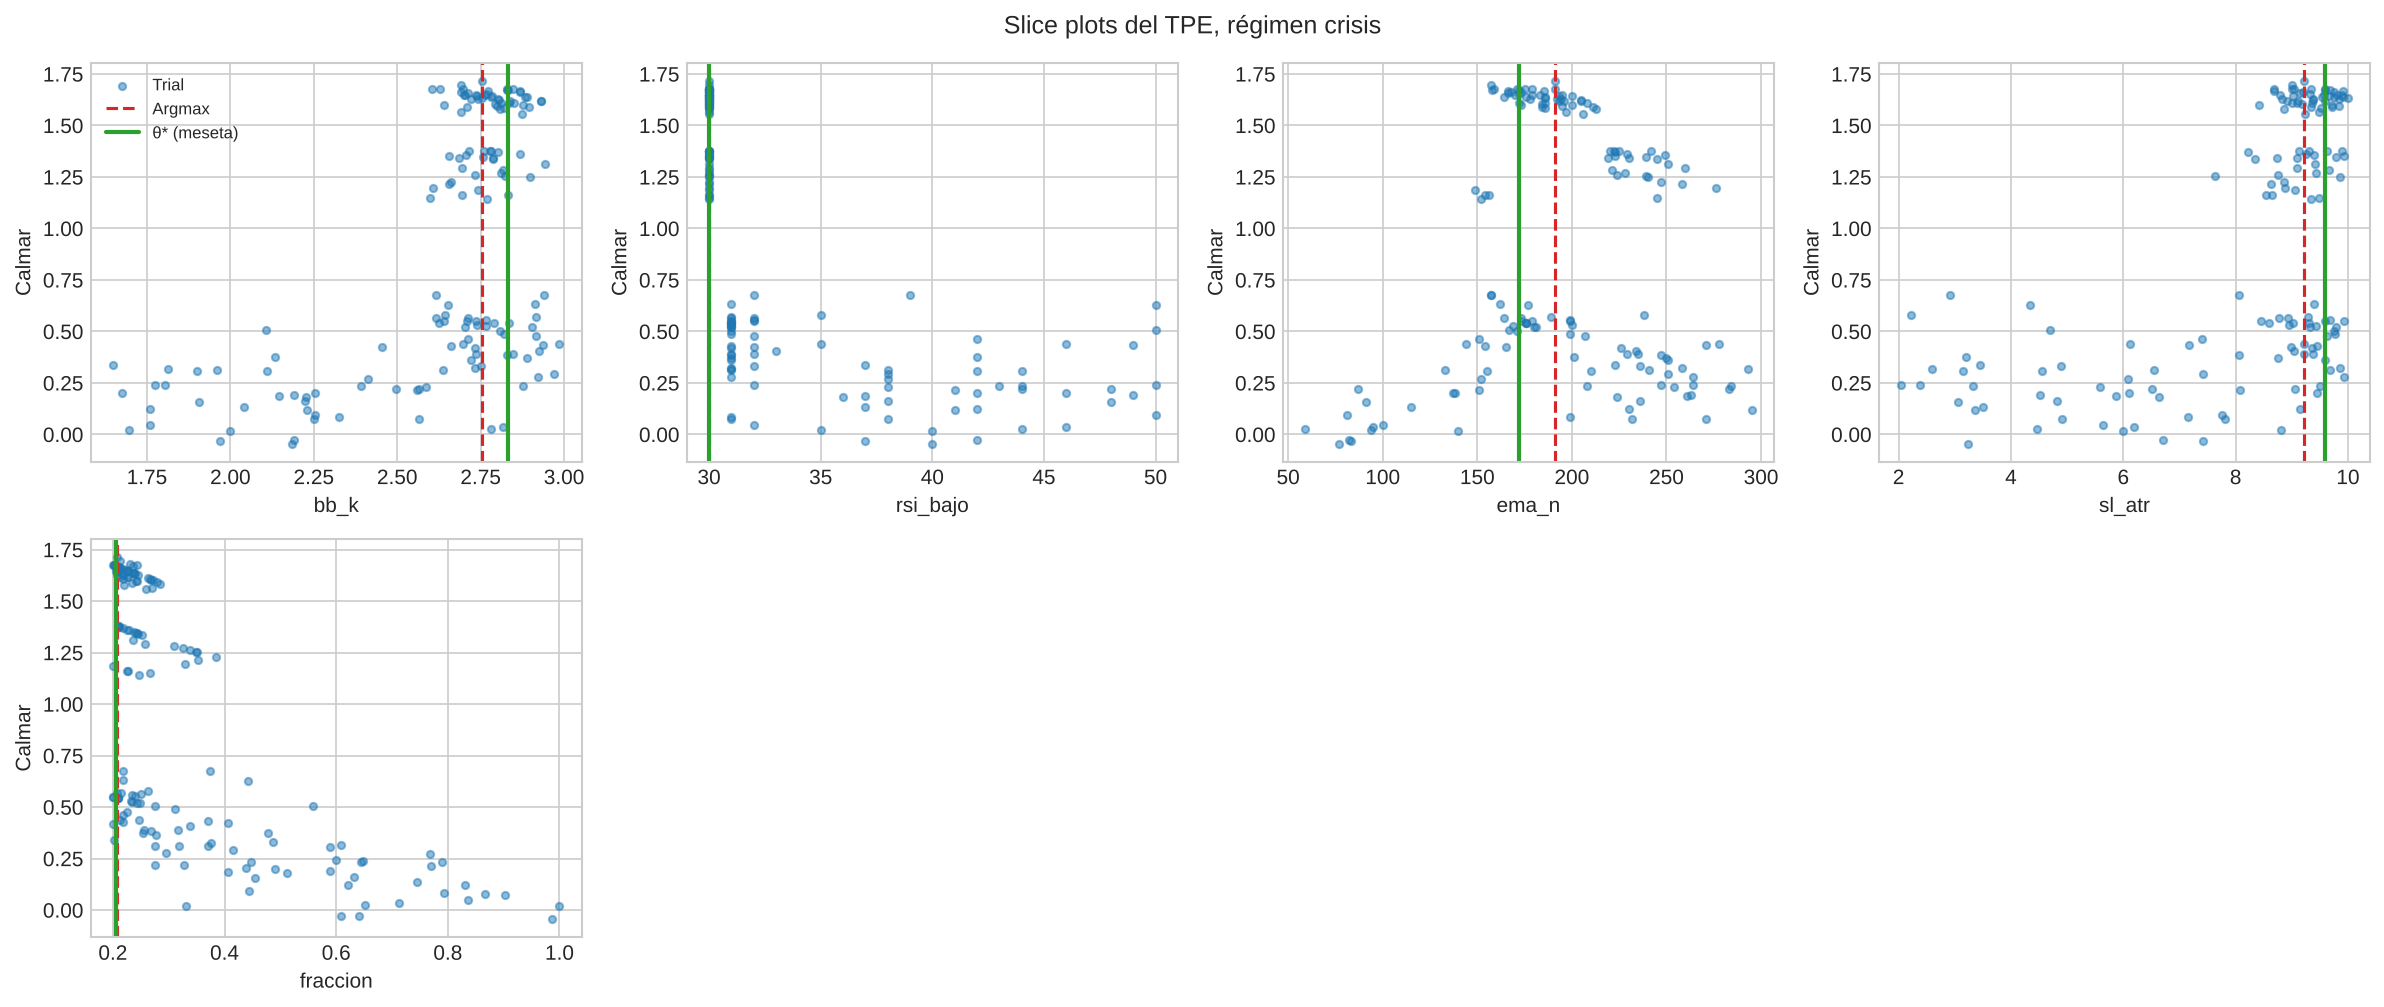

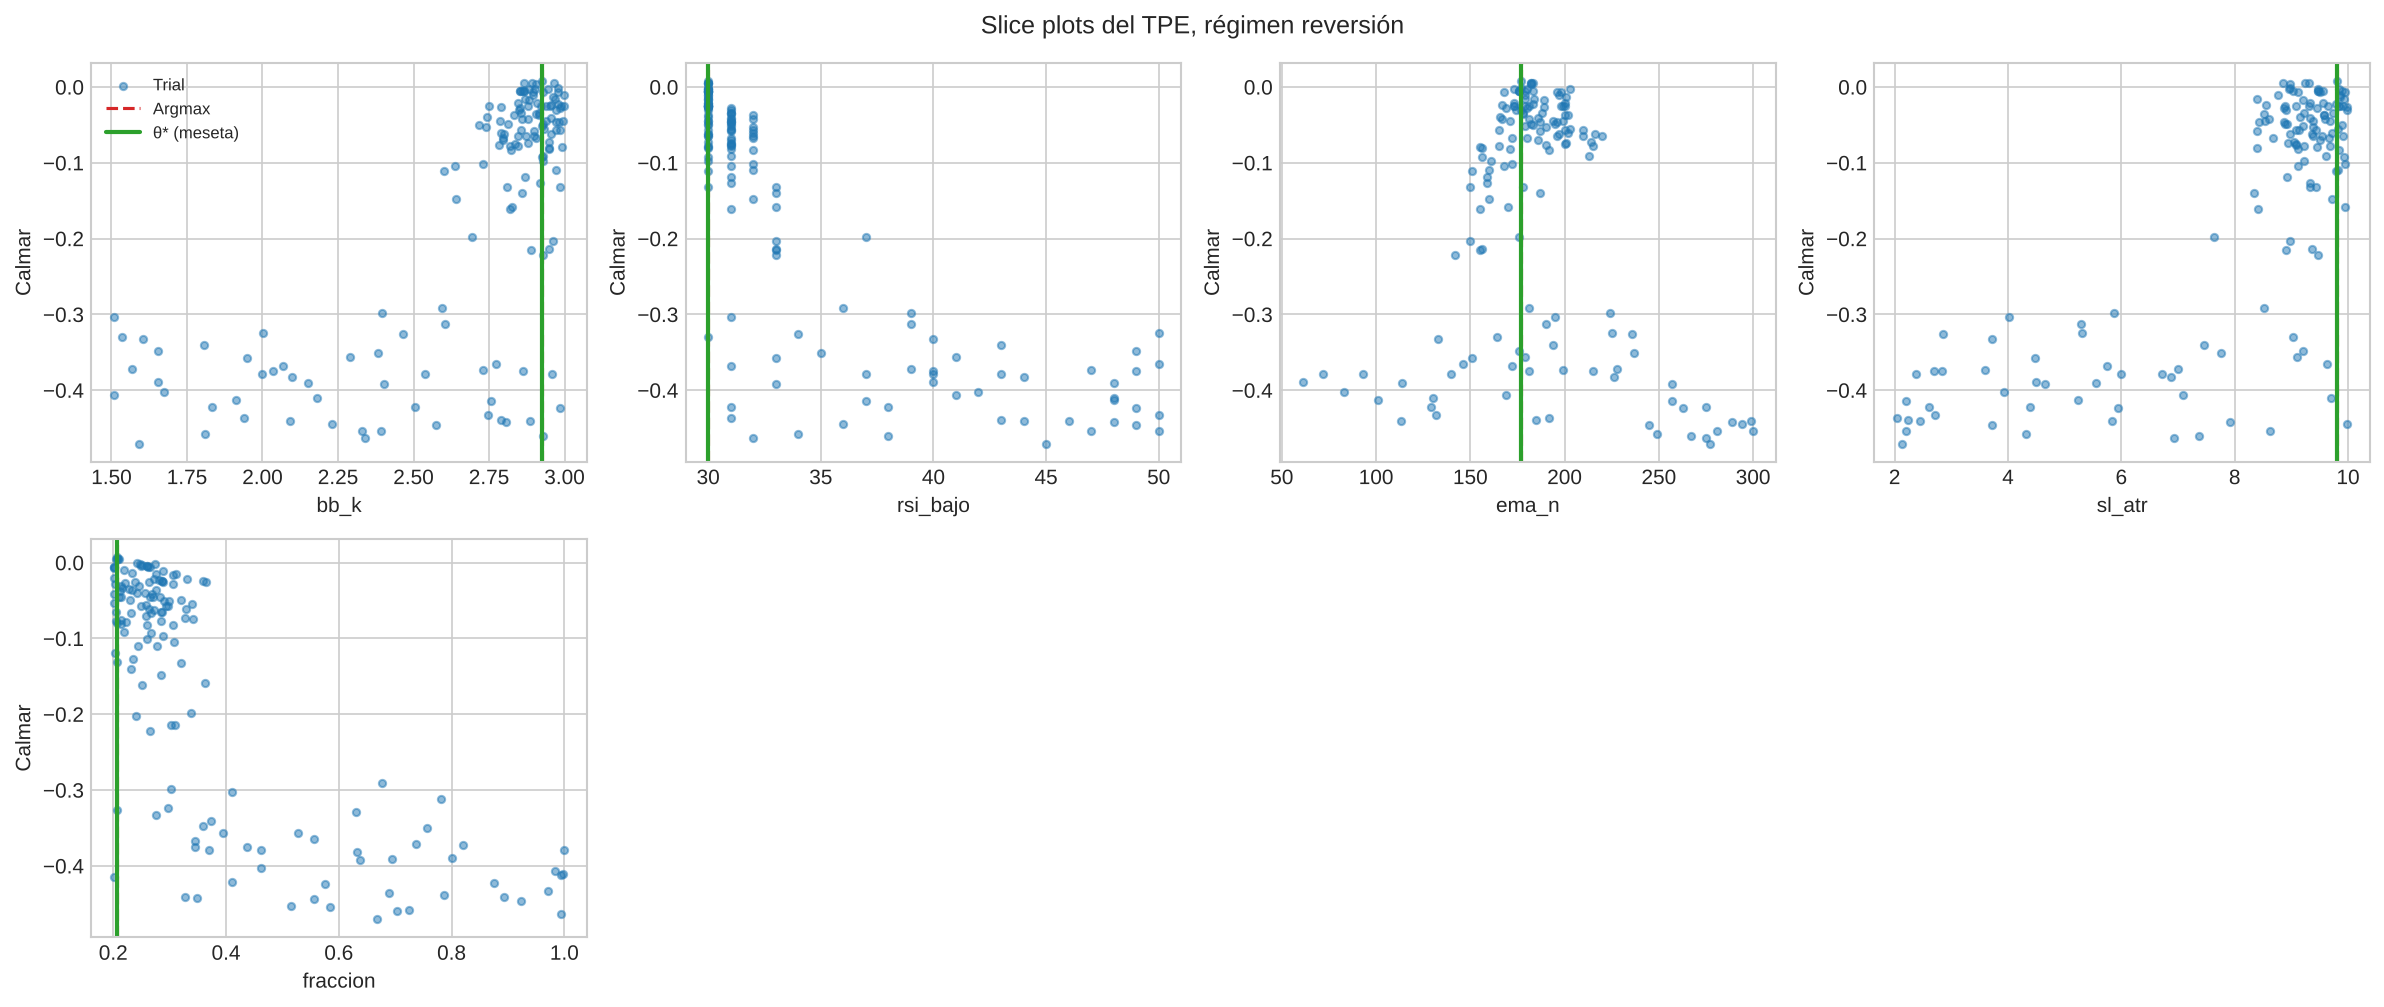

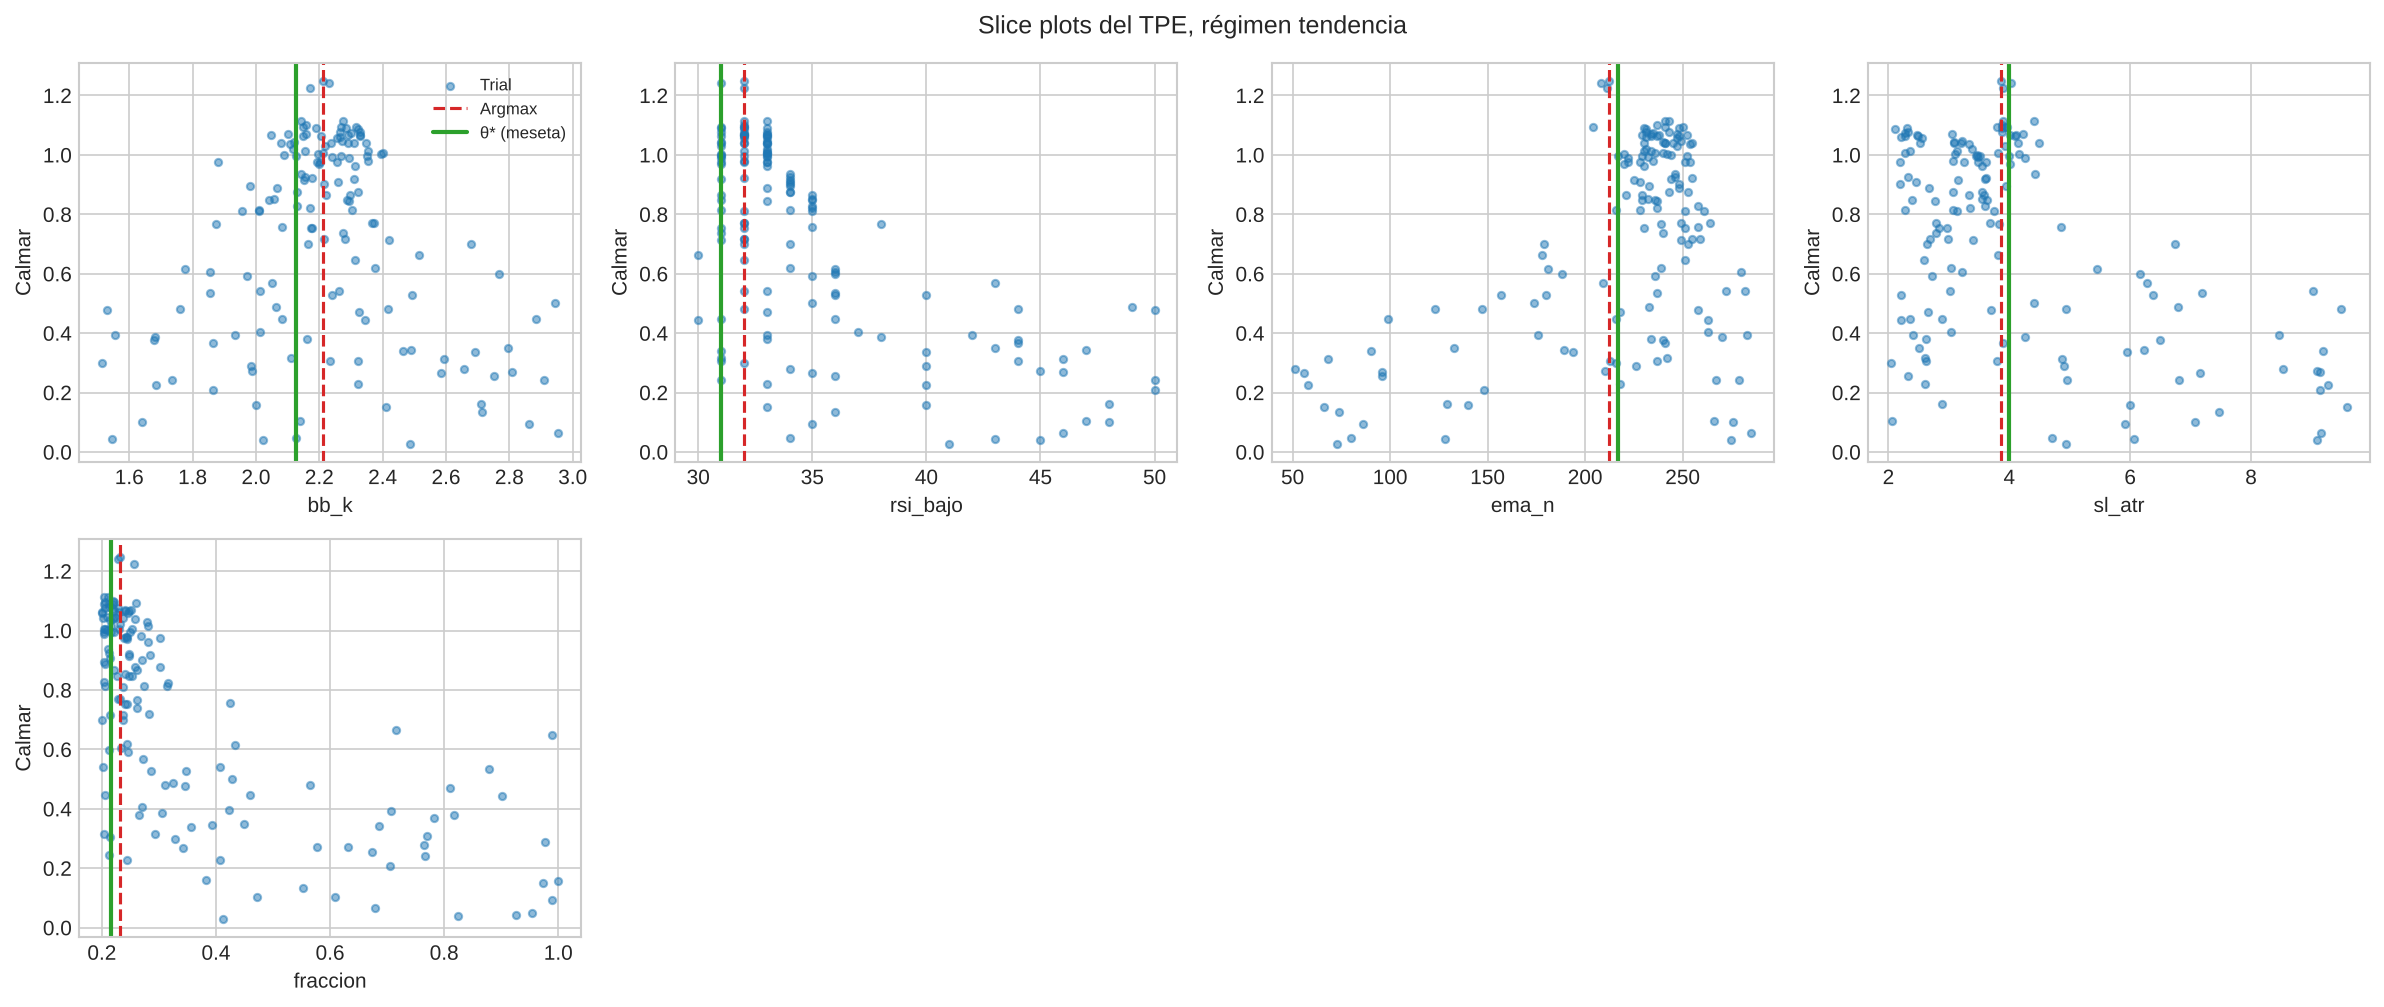

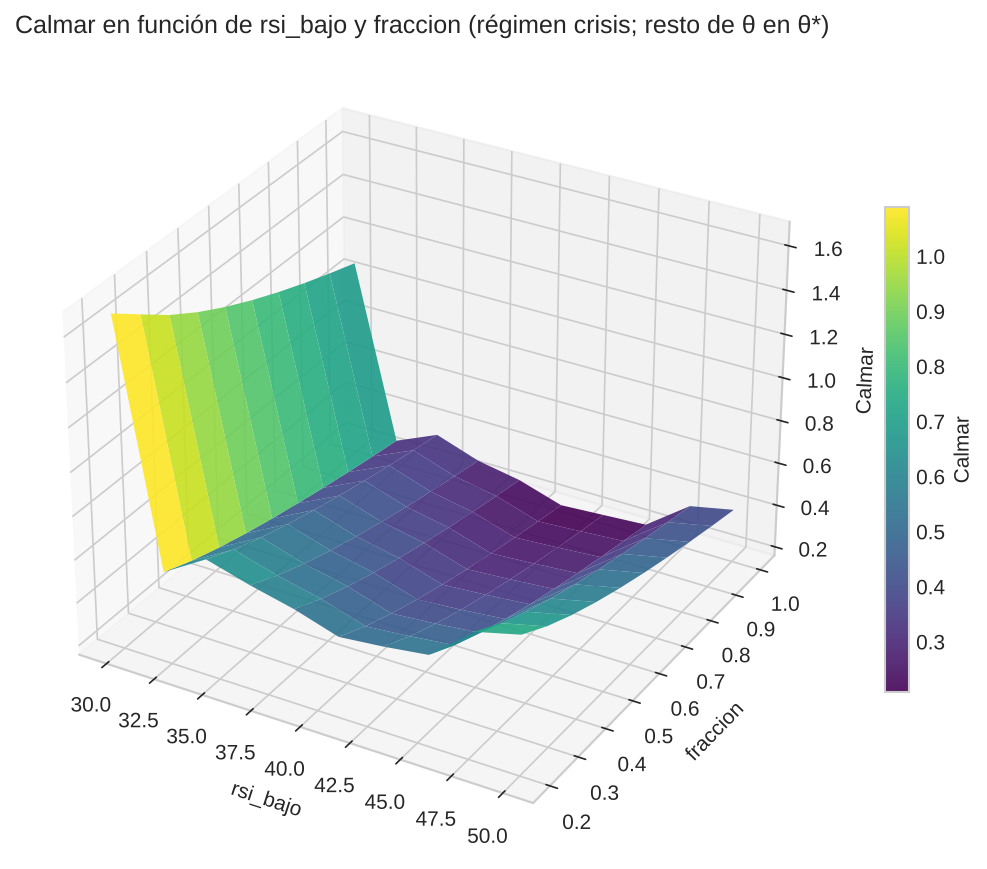

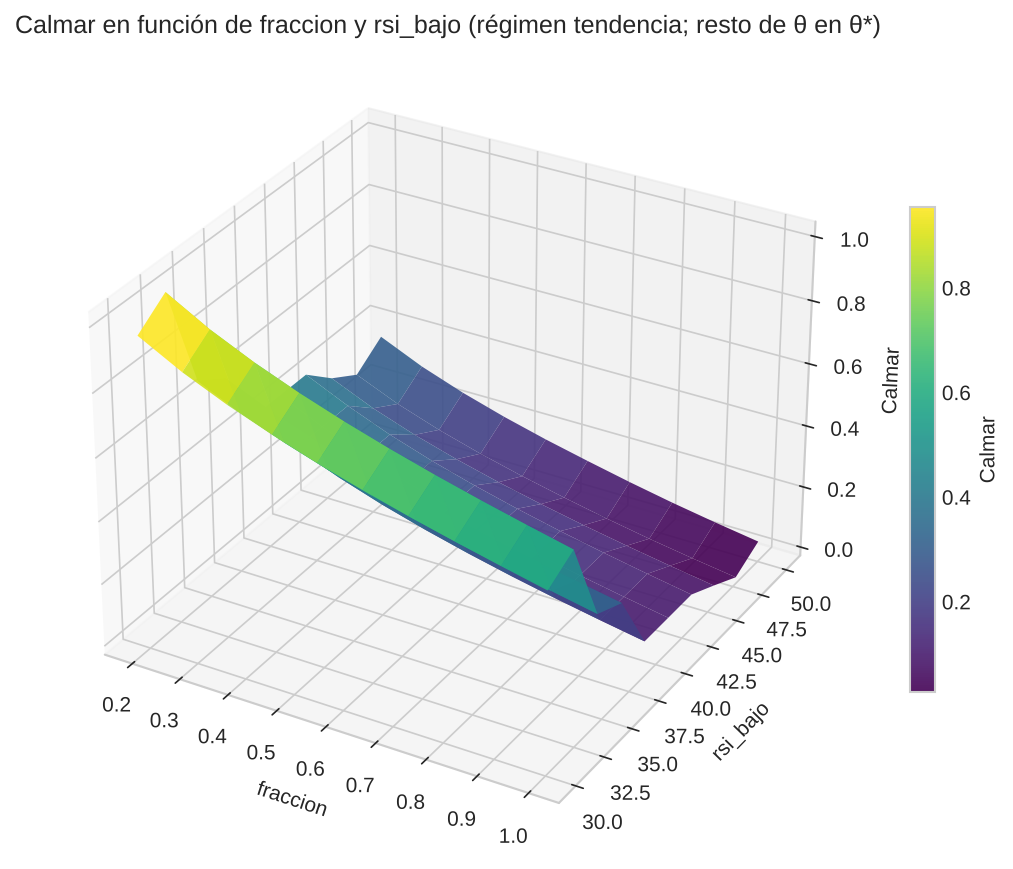

In [6]:
for f in ("11_historia_optimizacion.png", "12_importancia_parametros.png"):
    display(Image(F / f))
for f in sorted(F.glob("13_slices_*.png")) + sorted(F.glob("14_superficie_*.png")):
    display(Image(f))

## 6. Walk-forward (train + test; anchored oficial, rolling como comparación)

anchored {'ventanas': 23, 'configuraciones': 10350, 'segundos': 175.135, 'anualizado_dentro': 0.012, 'anualizado_fuera': 0.03, 'eficiencia': 2.445}


,train (WF),B&H train (WF),test (WF),B&H test (WF),WF completo,B&H WF completo
retorno_total,0.005,0.191,0.052,0.399,0.056,0.673
rendimiento_anualizado,0.004,0.150,0.093,0.804,0.030,0.326
volatilidad,0.057,0.197,0.060,0.210,0.058,0.201
sharpe,0.103,0.808,1.521,2.915,0.543,1.504
sortino,0.140,1.134,2.435,4.235,0.774,2.136
calmar,0.070,0.749,2.325,9.481,0.500,1.630
max_drawdown,-0.061,-0.200,-0.040,-0.085,-0.061,-0.200
win_rate,0.315,NaN,0.417,NaN,0.346,NaN
operaciones,54.000,1.000,24.000,1.000,78.000,1.000
turnover_anual,31.543,1.549,31.628,3.594,31.532,1.208


rolling {'ventanas': 23, 'configuraciones': 10350, 'segundos': 155.518, 'anualizado_dentro': 0.082, 'anualizado_fuera': -0.032, 'eficiencia': -0.393}


,train (WF),B&H train (WF),test (WF),B&H test (WF),WF completo,B&H WF completo
retorno_total,-0.070,0.191,0.013,0.399,-0.058,0.673
rendimiento_anualizado,-0.056,0.150,0.024,0.804,-0.032,0.326
volatilidad,0.055,0.197,0.050,0.210,0.054,0.201
sharpe,-1.028,0.808,0.493,2.915,-0.587,1.504
sortino,-1.393,1.134,0.698,4.235,-0.805,2.136
calmar,-0.473,0.749,0.703,9.481,-0.272,1.630
max_drawdown,-0.119,-0.200,-0.034,-0.085,-0.119,-0.200
win_rate,0.281,NaN,0.444,NaN,0.330,NaN
operaciones,64.000,1.000,27.000,1.000,91.000,1.000
turnover_anual,39.089,1.549,33.978,3.594,38.319,1.208


,inicio_test,calmar_dentro,calmar_fuera,retorno_dentro,retorno_fuera,anualizado_dentro,operaciones_fuera,activo_tendencia,activo_reversion,activo_crisis
0,2024-05-01,0.609,4.099,0.005,0.003,0.012,4,True,False,True
1,2024-06-03,0.738,-13.008,0.008,-0.004,0.015,1,True,False,False
2,2024-07-01,-0.580,2.609,-0.018,0.002,-0.028,3,True,True,True
3,2024-08-01,-0.012,59.689,-0.000,0.021,-0.000,3,True,True,True
4,2024-09-03,1.225,-10.572,0.079,-0.032,0.100,2,True,True,False
5,2024-10-01,0.548,-7.516,0.020,-0.019,0.022,8,True,True,True
6,2024-11-01,-0.337,-1.852,-0.009,-0.001,-0.009,1,True,True,False
7,2024-12-02,0.150,2.433,0.005,0.001,0.004,4,True,True,True
8,2025-01-02,0.071,-0.684,0.006,-0.000,0.005,4,True,True,True
9,2025-02-03,-0.072,-0.743,-0.006,-0.001,-0.005,3,True,True,True


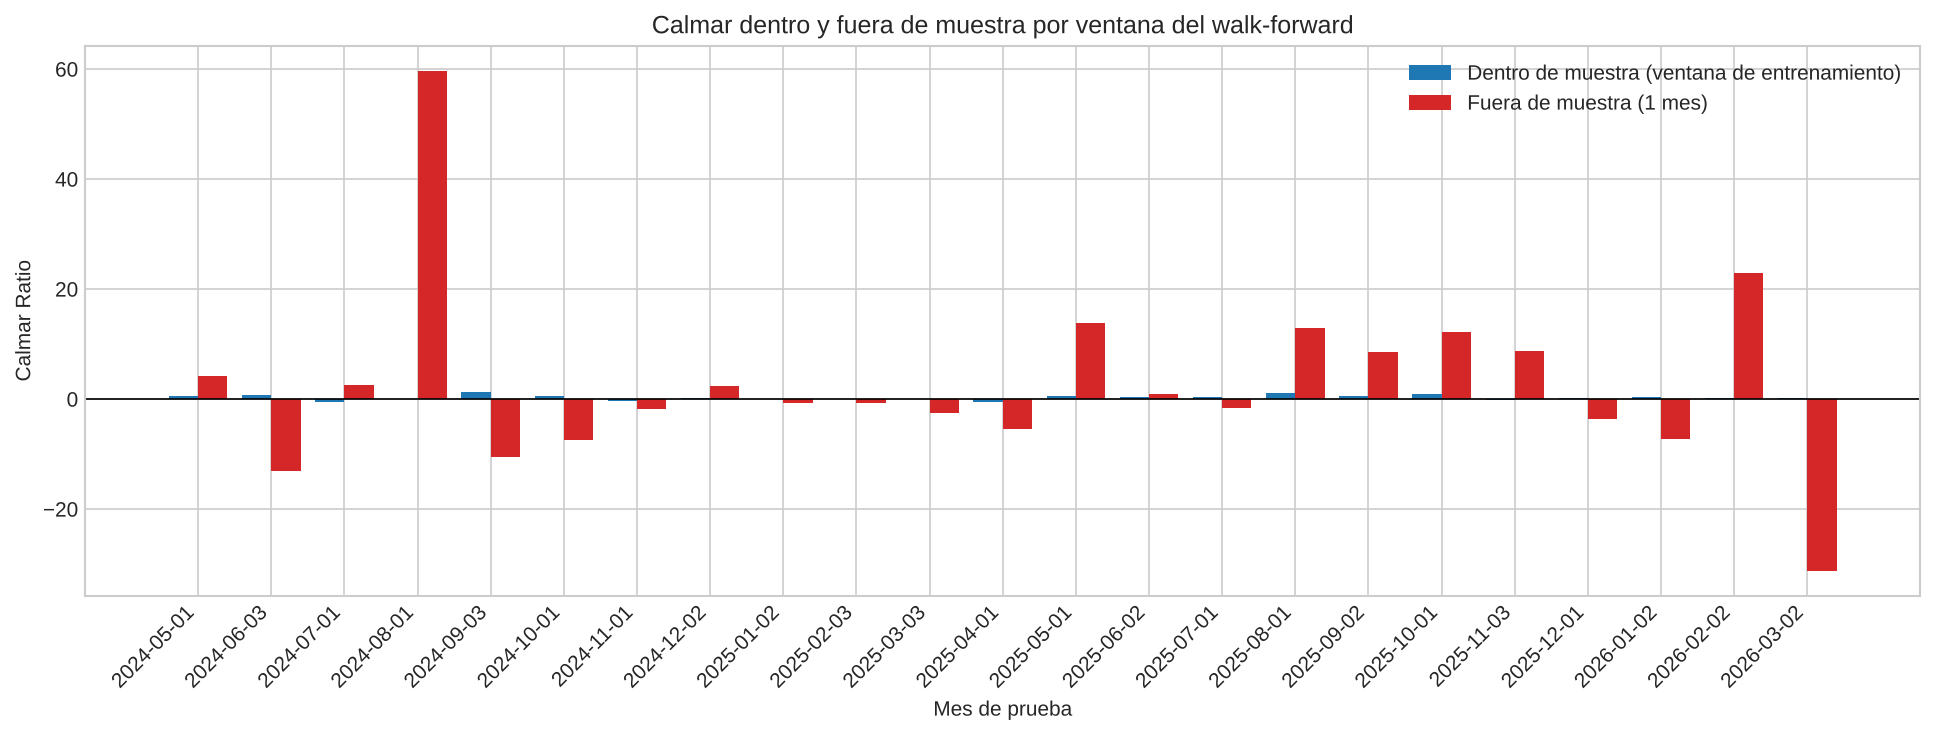

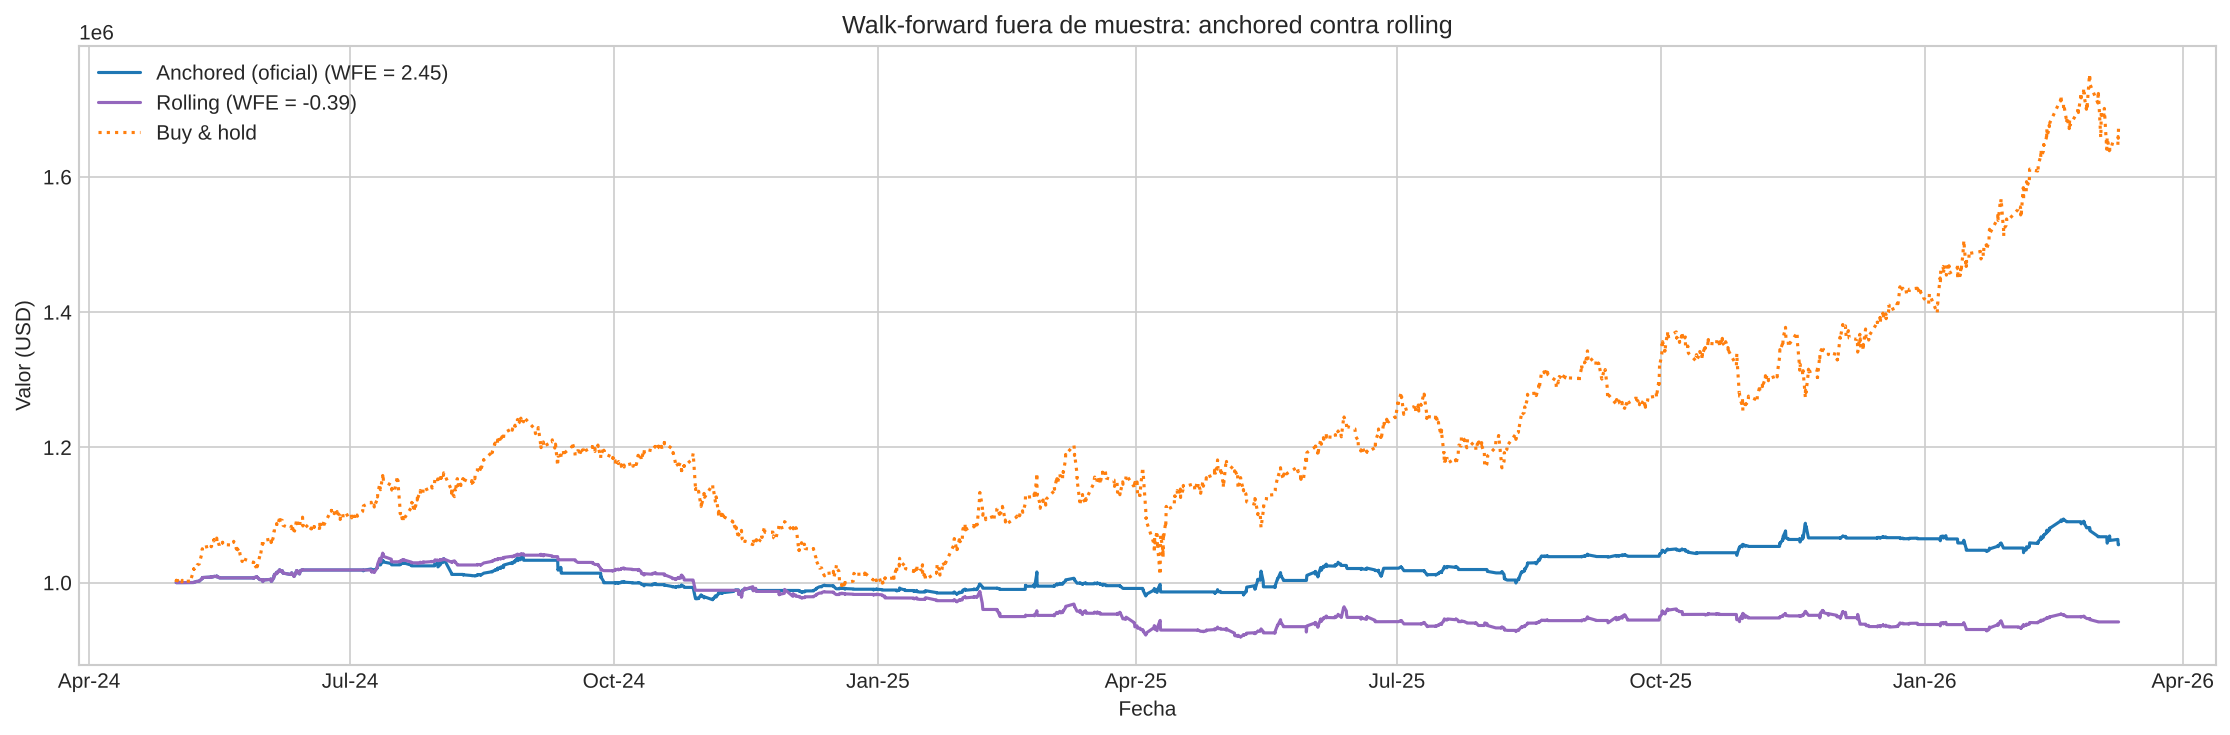

In [7]:
for modo in ("anchored", "rolling"):  # anchored es el oficial
    print(modo, {k: round(v, 3) if isinstance(v, float) else v
                 for k, v in resumen["walk_forward"][modo].items() if k != "tabla"})
    display(pd.read_csv(R / f"walk_forward_{modo}_vs_bh.csv", index_col=0).round(3))
display(pd.read_csv(R / "walk_forward_anchored.csv").round(3))
for f in ("10_walk_forward.png", "15_anchored_rolling.png"):
    display(Image(F / f))

## 7. Resultados: train (WF), test (WF) y validation contra buy & hold

,train (WF),B&H train,test (WF),B&H test,validation,B&H validation
retorno_total,0.0053,0.1913,0.0519,0.3987,-0.0591,-0.1309
rendimiento_anualizado,0.0043,0.1501,0.0931,0.8043,-0.1000,-0.2152
volatilidad,0.0574,0.1973,0.0597,0.2101,0.0324,0.2972
sharpe,0.1029,0.8076,1.5213,2.9153,-3.2339,-0.6626
sortino,0.1398,1.1336,2.4350,4.2352,-3.6944,-0.8506
calmar,0.0703,0.7494,2.3253,9.4810,-1.4732,-1.3554
max_drawdown,-0.0607,-0.2002,-0.0401,-0.0848,-0.0678,-0.1588
win_rate,0.3148,NaN,0.4167,NaN,0.1923,NaN
operaciones,54.0000,1.0000,24.0000,1.0000,26.0000,1.0000
turnover_anual,31.5426,1.5488,31.6279,3.5938,18.6033,3.4601


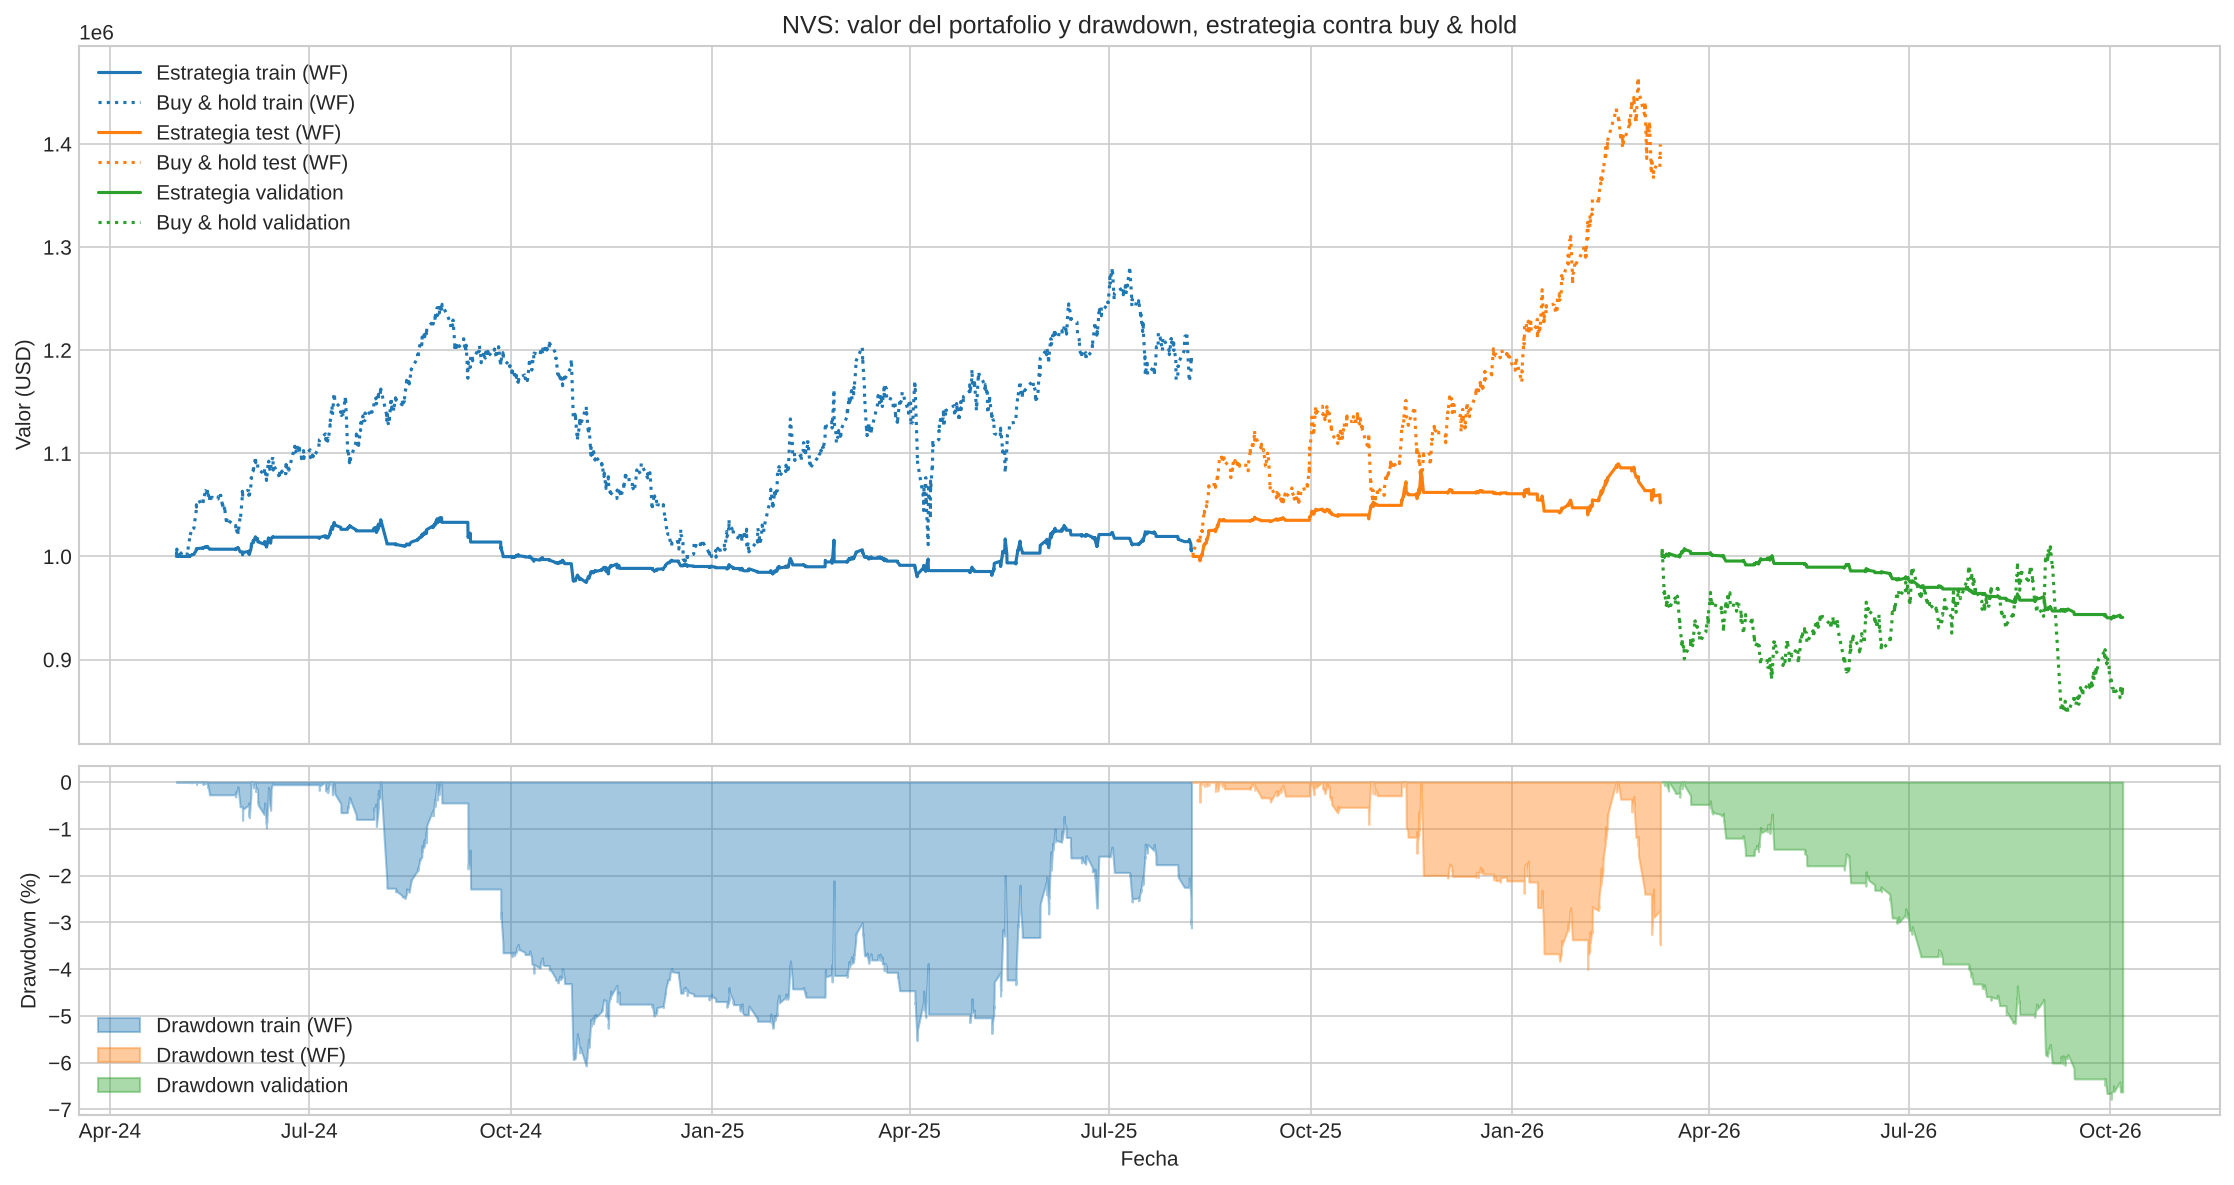

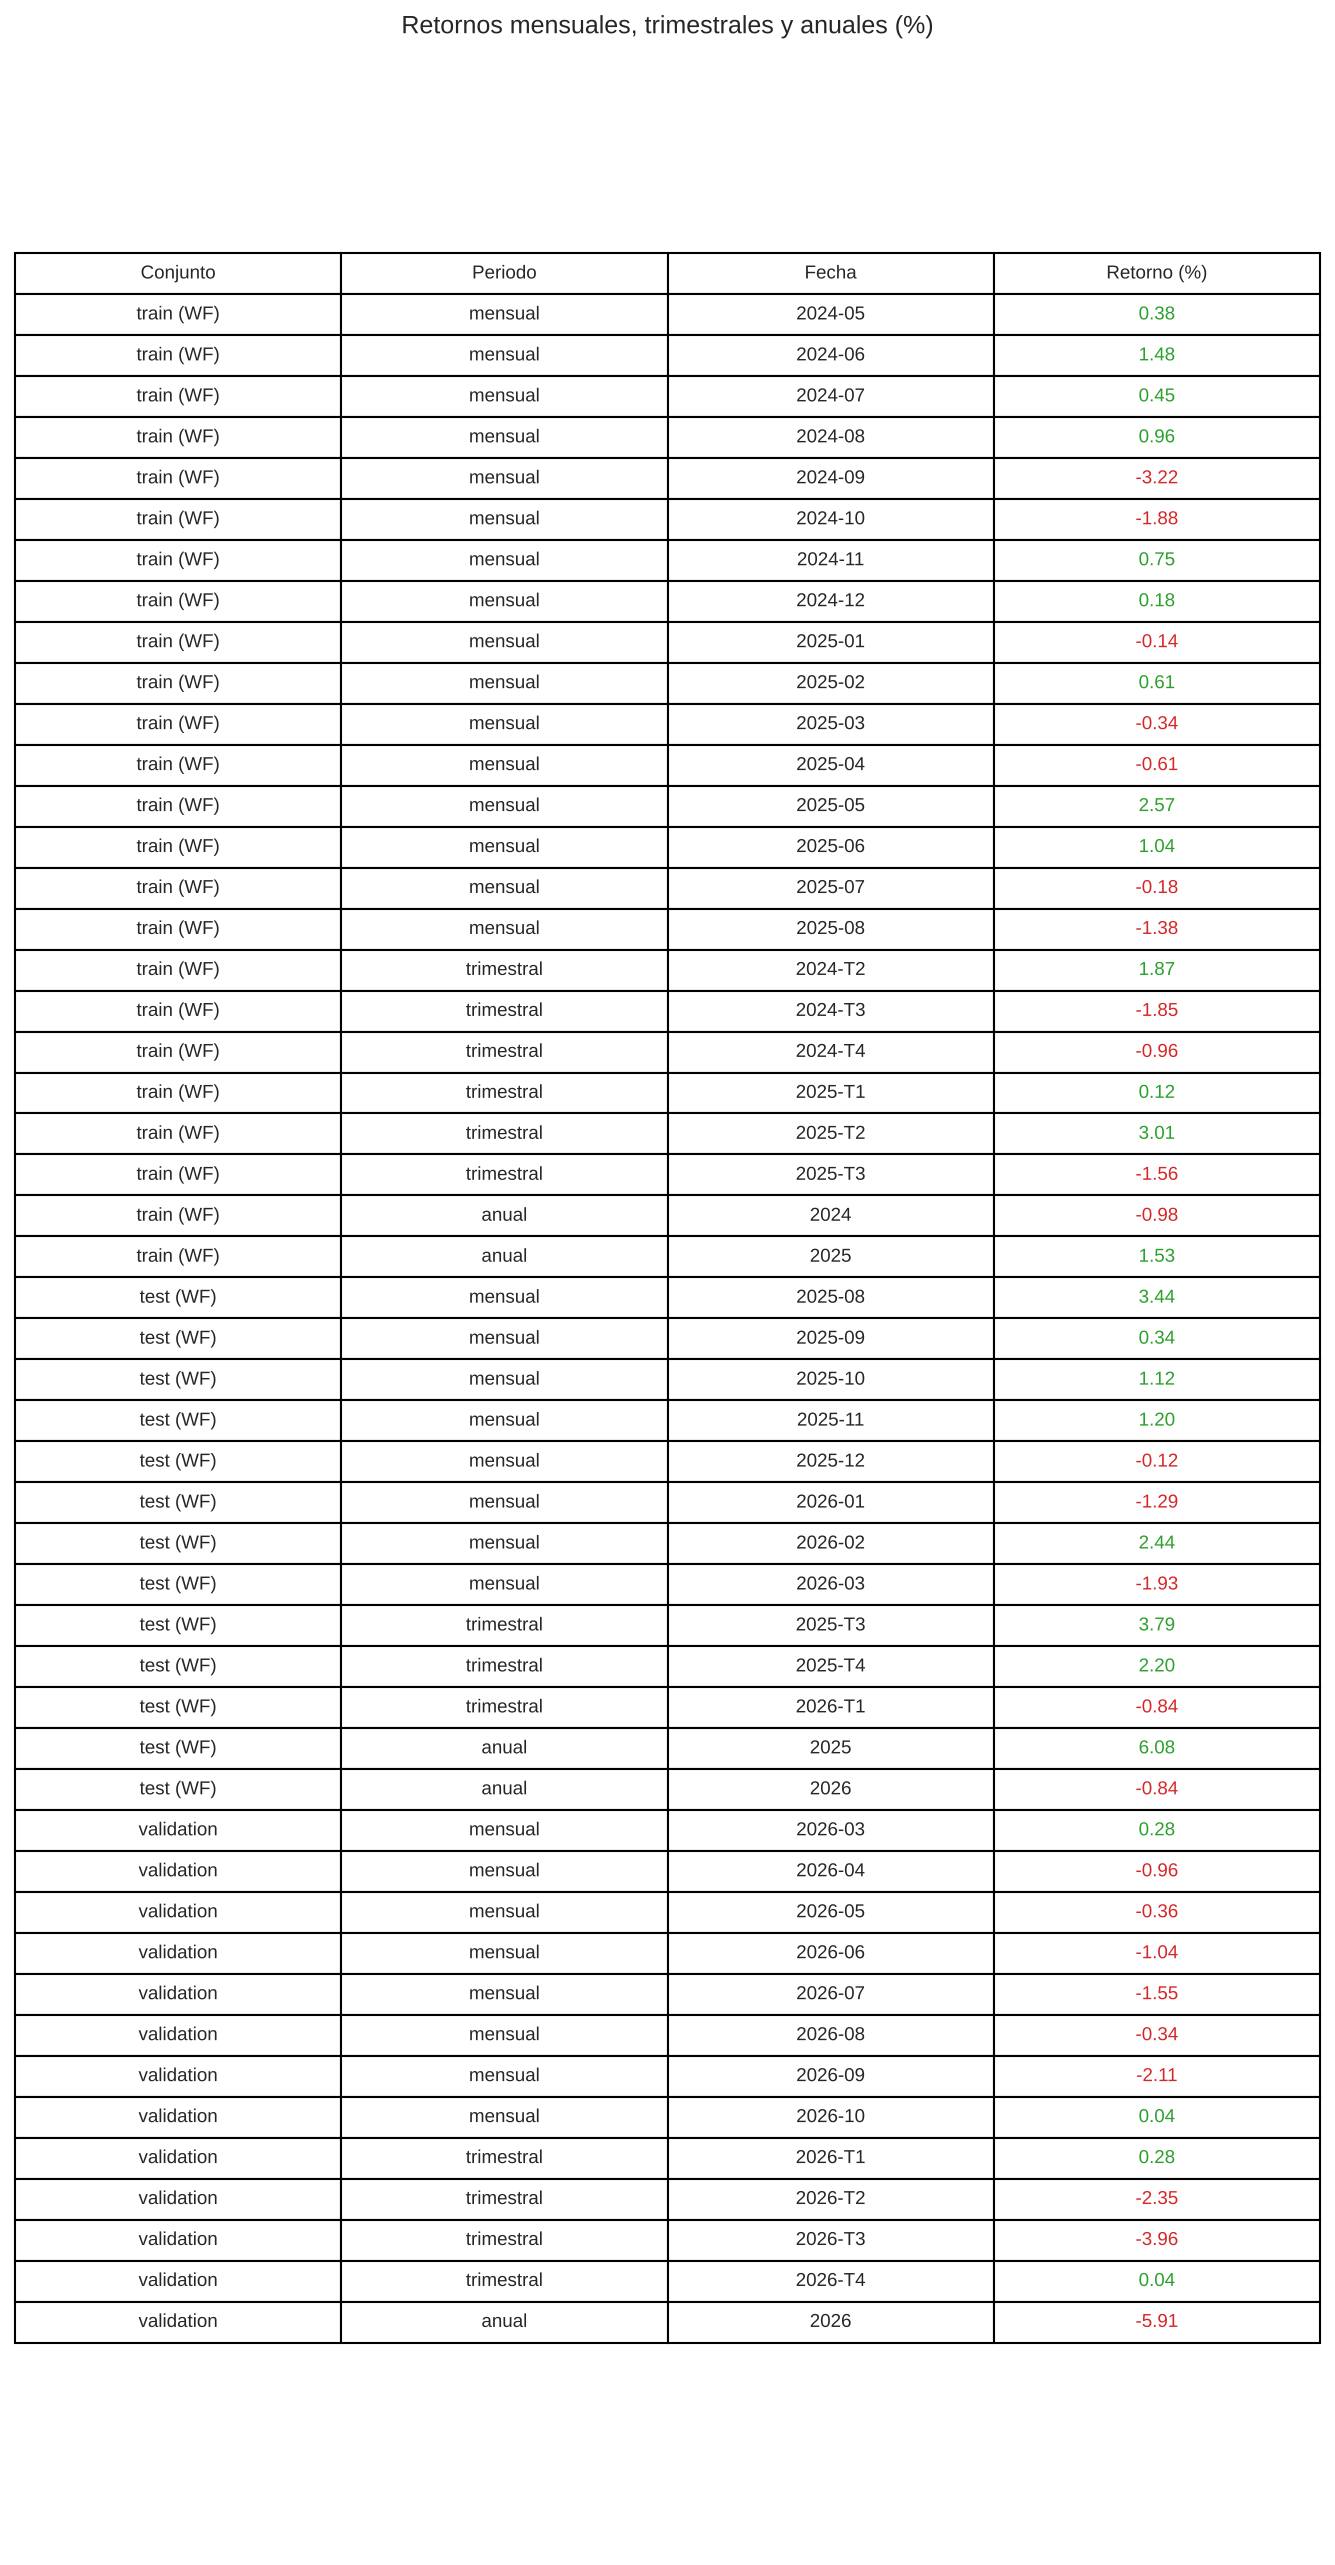

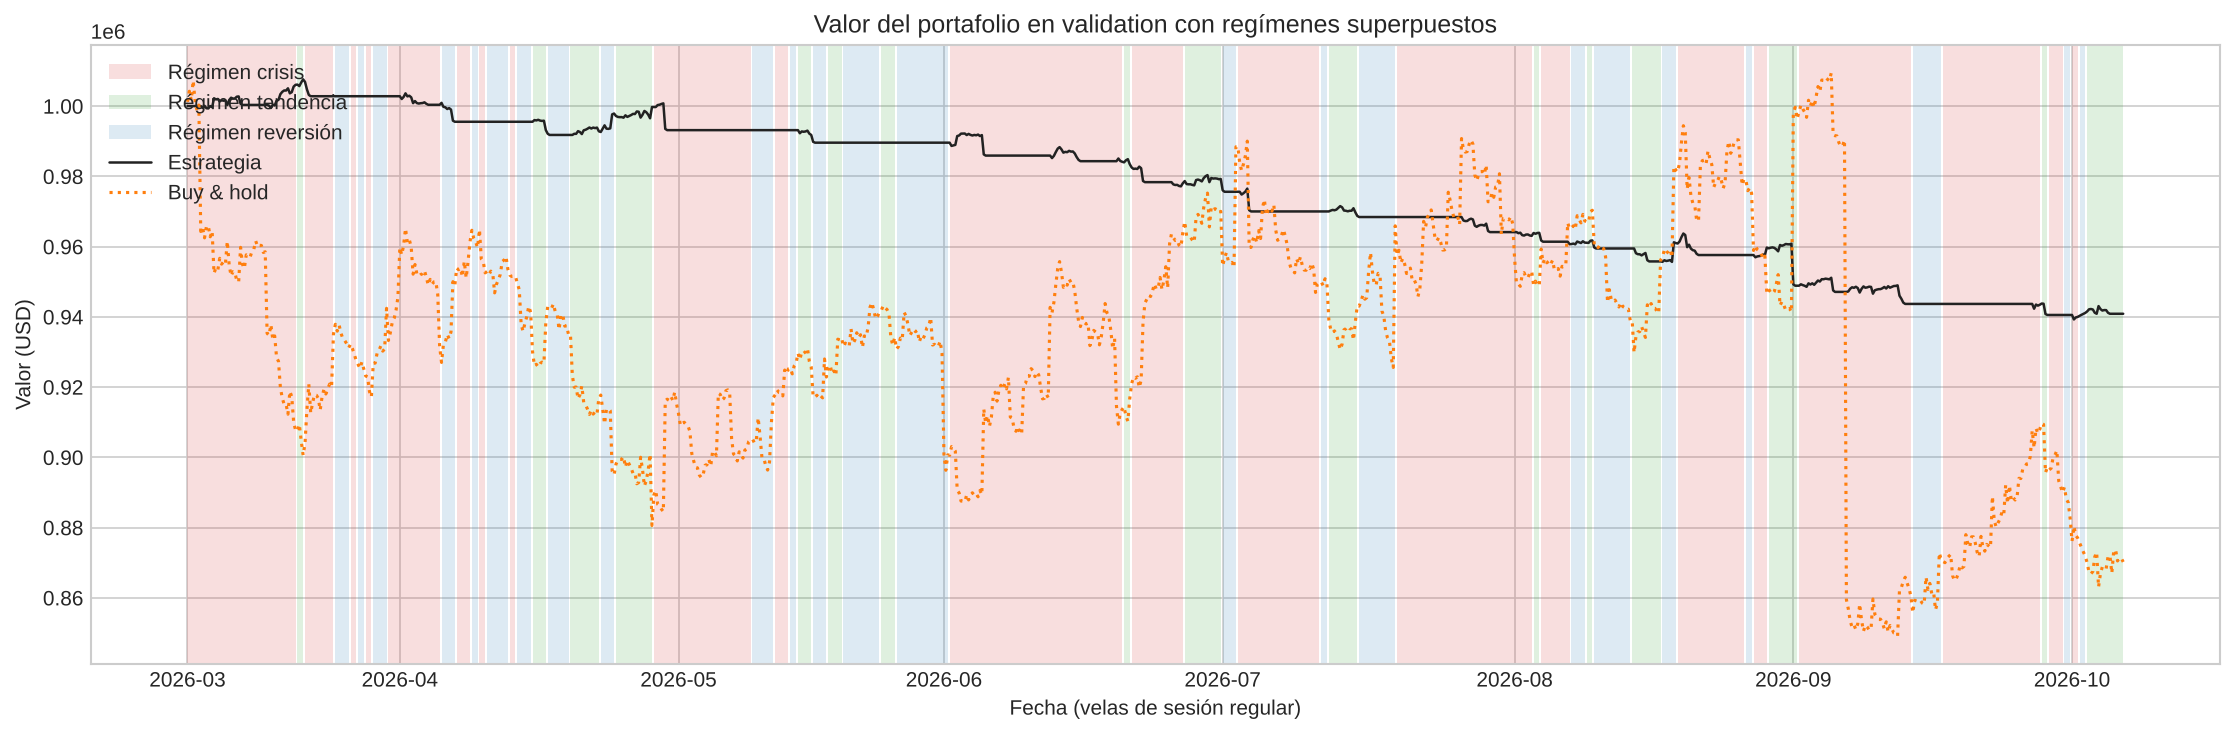

In [8]:
display(pd.read_csv(R / "metricas.csv", index_col=0).round(4))
for f in ("03_valor_drawdown.png", "04_tabla_retornos.png", "09_valor_regimenes.png"):
    display(Image(F / f))

## 8. Desempeño por régimen

In [9]:
display(pd.read_csv(R / "metricas_por_regimen.csv", index_col=0).round(4))
resumen["kruskal"]

,proporcion_tiempo,retorno_acumulado,sharpe,sortino,operaciones,win_rate,pnl
crisis,0.5926,-0.0403,-4.1067,-4.5323,19.0,0.1579,-54536.2723
reversion,0.2351,-0.0027,-0.7665,-1.2337,0.0,NaN,0.0000
tendencia,0.1724,-0.0169,-3.5505,-3.8714,7.0,0.2857,-4594.3942


{'estadistico': 0.0962293525923883, 'p_valor': 0.9530244914919515, 'grupos': 3}

## 9. Robustez: regla de confirmación, sensibilidad ±20% y costos

,operaciones,calmar,retorno_total,win_rate,turnover_anual
dos_de_tres,26.0,-1.4732,-0.0591,0.1923,18.6033
estricta,14.0,-1.4290,-0.0378,0.2143,10.0960
solo_bollinger,17.0,-1.4681,-0.0459,0.2353,12.3381
solo_rsi,28.0,-1.4620,-0.0555,0.1786,19.9185
solo_estocastico,42.0,-1.5742,-0.0746,0.1667,30.0085


,-20%,base,+20%
parametro,,,
tendencia·bb_k,-1.475,-1.473,-1.473
tendencia·rsi_bajo,-1.479,-1.473,-1.478
tendencia·ema_n,-1.473,-1.473,-1.473
tendencia·sl_atr,-1.473,-1.473,-1.473
tendencia·fraccion,-1.470,-1.473,-1.476
crisis·bb_k,-1.623,-1.473,-1.452
crisis·rsi_bajo,-1.480,-1.473,-1.471
crisis·ema_n,-1.473,-1.473,-1.464
crisis·sl_atr,-1.476,-1.473,-1.473


,ida_vuelta_bps,retorno_neto,sharpe,calmar,operaciones
0,0,-0.0410,-2.2226,-1.3628,26
1,10,-0.0462,-2.5128,-1.4022,26
2,20,-0.0513,-2.8004,-1.4347,26
3,30,-0.0564,-3.0846,-1.4619,26
4,40,-0.0615,-3.3647,-1.4847,26
5,50,-0.0665,-3.6399,-1.5041,26
6,60,-0.0715,-3.9096,-1.5208,26
7,70,-0.0765,-4.1731,-1.5351,26
8,80,-0.0815,-4.4299,-1.5474,26
9,90,-0.0864,-4.6795,-1.5582,26


,ida_vuelta_bps,retorno_neto,sharpe,calmar,operaciones
0,0,0.1829,1.6306,2.2275,79
1,10,0.1492,1.3549,1.6618,79
2,20,0.1164,1.0781,1.1968,79
3,30,0.0846,0.8010,0.8086,79
4,40,0.0537,0.5248,0.4803,79
5,50,0.0238,0.2505,0.1969,79
6,60,-0.0054,-0.0211,-0.0391,79
7,70,-0.0336,-0.2890,-0.2149,79
8,80,-0.0611,-0.5525,-0.3284,79
9,90,-0.0878,-0.8107,-0.4088,79


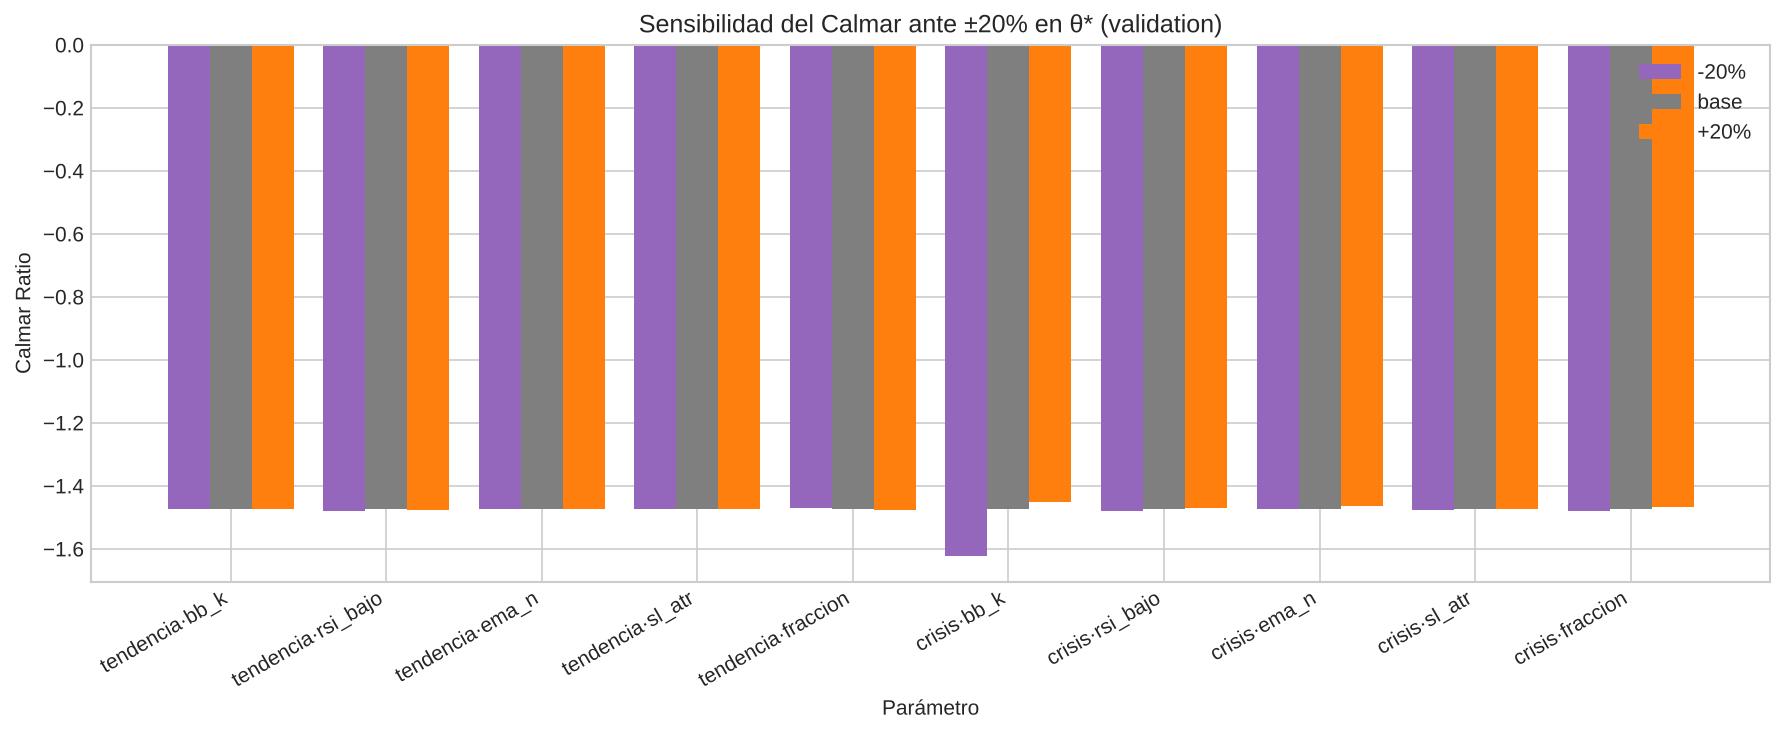

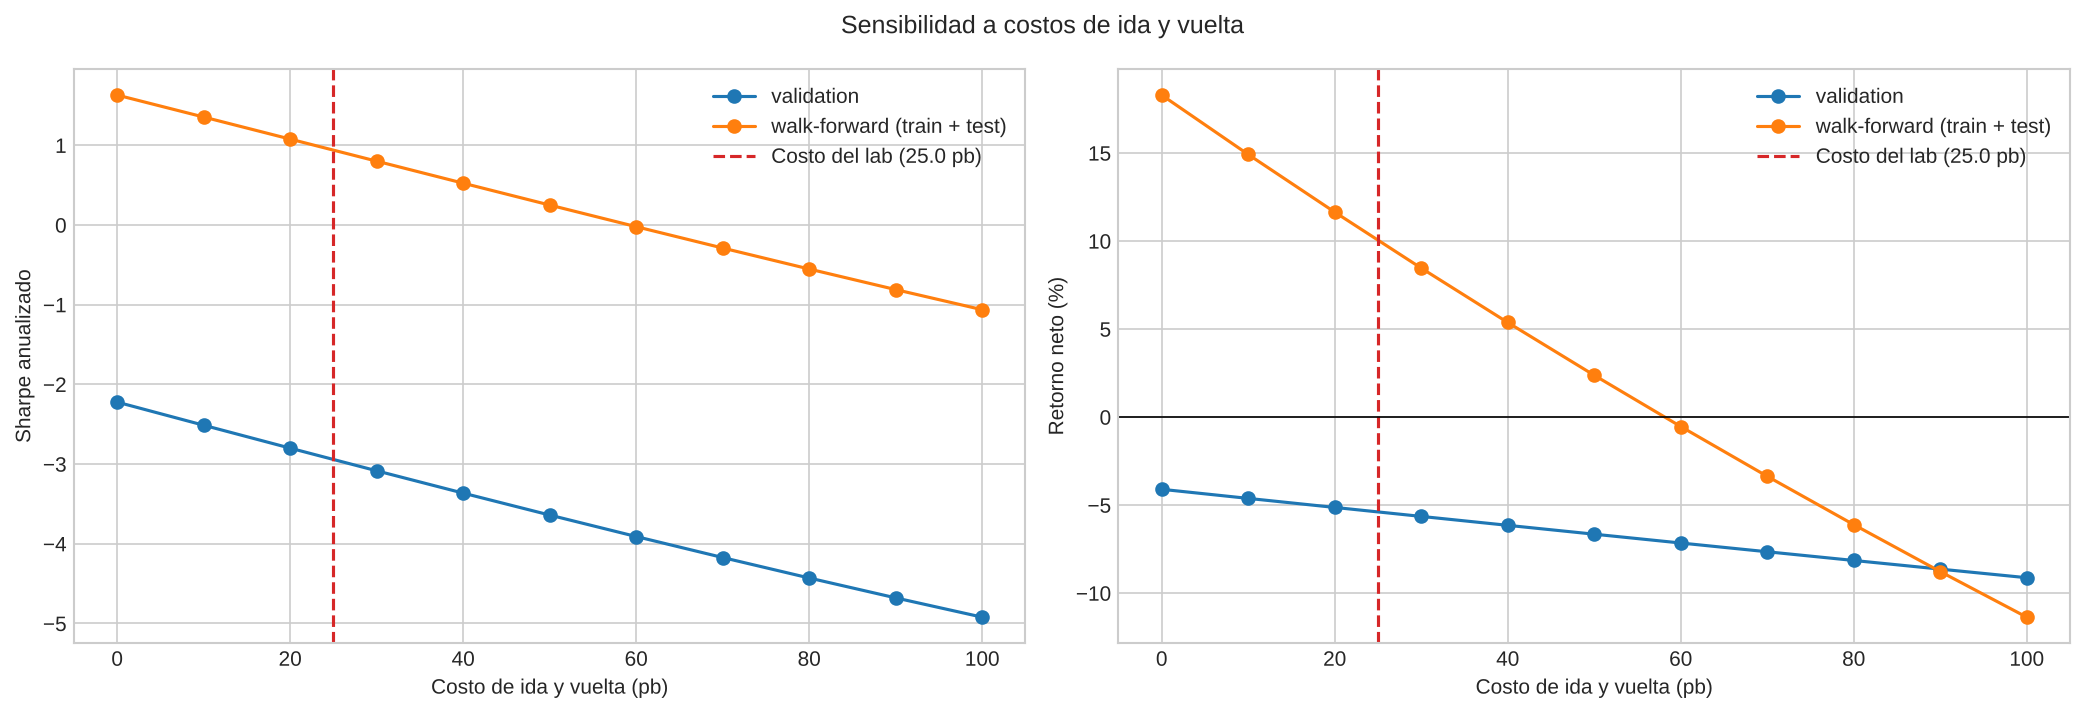

In [10]:
display(pd.read_csv(R / "reglas.csv", index_col=0).round(4))
display(pd.read_csv(R / "sensibilidad.csv", index_col=0).round(3))
display(pd.read_csv(R / "costos_validation.csv").round(4))
display(pd.read_csv(R / "costos_walk_forward.csv").round(4))
for f in ("05_sensibilidad.png", "06_costos.png"):
    display(Image(F / f))

## 10. Benchmark con la misma exposición, bootstrap y extensiones (solo walk-forward)

In [11]:
display(pd.read_csv(R / "exposicion_bootstrap.csv", index_col=0).round(4))
ruta = R / "extensiones.csv"
if ruta.exists():
    display(pd.read_csv(ruta, index_col=0).round(4))
else:
    print("Corre python main.py --extensiones para generar la tabla de extensiones.")

,walk-forward,validation
exposicion_media,0.1809,0.0777
retorno_estrategia,0.0559,-0.0591
retorno_bh_misma_exposicion,0.1039,-0.0089
calmar_estrategia,0.4997,-1.4732
calmar_bh_misma_exposicion,1.4307,-1.2089
dd_bh_misma_exposicion,-0.0390,-0.0126
media_por_operacion,0.0019,-0.0114
ic95_bajo,-0.0030,-0.0171
ic95_alto,0.0073,-0.0052
p_valor_media_positiva,0.2327,0.9994


,descripcion,retorno_total,calmar,max_drawdown,sharpe,win_rate,operaciones,turnover_anual,exposicion_media,eficiencia
oficial,diseño congelado,0.0559,0.4997,-0.0607,0.5433,0.3462,78,31.5315,0.1809,2.4454
trailing_stop,trailing stop en ATR en lugar de salir en la m...,0.0091,0.0300,-0.1665,0.1000,0.4286,77,40.3554,0.3780,0.1101
tres_de_tres,confirmación 3 de 3 en lugar de 2 de 3,-0.0588,-0.3560,-0.0919,-0.6320,0.3462,52,22.8013,0.1184,-1.0336
fraccion_100,fracción fija de 100% del equity (Optuna no la...,-0.0796,-0.2123,-0.2097,-0.3230,0.3333,66,72.2394,0.3650,-2.0156
